# Lifecycle EDA — bảng gọn và nhận xét tại chỗ
Giữ nguyên lifecycle-v1 và ngưỡng 2/3/2. Mỗi ô có kết quả chính đều có nhận xét bên dưới: số liệu → ý nghĩa → giới hạn.

- Output hiển thị được rút gọn từ **kết quả đã chạy trong notebook bạn gửi**, không phải lần chạy Parquet mới trong phiên chỉnh sửa.
- Nhận xét ghi rõ **snapshot 01/2015–05/2016**; nếu đổi input/thời gian/rule, cần cập nhật nhận xét.
- `SHOW_DETAILS=False`: chỉ bảng chính. Chuyển `True` để xem bảng phụ/audit/biểu đồ theo tháng. Dữ liệu tổng hợp và CSV đầy đủ vẫn được tạo.
- **Run All** với input RFM để chạy code đã chỉnh bố cục. Báo cáo `lifecycle-eda-report-updated.md` lưu cả kết quả mới và những hiển thị đã lược.

New là mới trong panel; Churned là proxy vắng dài hạn. Không cần sửa rule chỉ vì các nhóm có một số hành vi chồng nhau.


## Output dùng cho Affinity
Bản này thêm xuất toàn bộ khách–tháng vào `lifecycle_eda/customer_lifecycle/customer_lifecycle_YYYY-MM.parquet`, kèm manifest. Chạy lại ô cấu hình và vòng lặp toàn period để tạo output. Các rule và công thức EDA giữ nguyên. Output lưu sẵn trong notebook trước khi sửa không chứng minh export đã chạy.


In [1]:
import dataclasses, json, os, re
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
INPUT_DIR = None  # thư mục RFM output hoặc customer_month_features
OUTPUT_DIR = Path('/kaggle/working/lifecycle_eda' if Path('/kaggle/working').exists() else './lifecycle_eda')
START_MONTH, END_MONTH = '2015-01', '2016-05'
SAMPLE_MOD = 500  # lịch sử mẫu: customer_id % SAMPLE_MOD == 0; thống kê chính dùng toàn bộ khách
FILE_RE = re.compile(r'^customer_features_(\d{4})-(\d{2})\.parquet$')
CONFIG_PATH = OUTPUT_DIR / 'unused_rules.json'  # chỉ đáp ứng default của hàm gốc; không đọc/ghi file này

# True: mở bảng phụ, chart phụ và lịch sử audit; False: chỉ hiển thị kết quả chính.
SHOW_DETAILS = False

def show_compact(df, columns=None, pct=(), labels=None):
    view = df.loc[:,columns].copy() if columns is not None else df.copy()
    for col in pct:
        if col in view:
            view[col] = view[col].map(lambda v: 'NA' if pd.isna(v) else f'{v*100:.2f}%')
    display(view.rename(columns=labels or {}))

# Output đầy đủ cho Affinity, không dùng history_sample.parquet.
EXPORT_CUSTOMER_MONTH = True
LIFECYCLE_MONTHLY_DIR = OUTPUT_DIR / 'customer_lifecycle'
if EXPORT_CUSTOMER_MONTH: LIFECYCLE_MONTHLY_DIR.mkdir(parents=True, exist_ok=True)


## 1. Rule gốc và kiểm tra đầu vào
Các ô dưới được sao chép nguyên văn phần hàm từ notebook lifecycle của bạn. Không chạy lại phần stage-1 trial/self-test của notebook cũ.

In [2]:
CORE_COLS = ['customer_id', 'as_of_month', 'is_observed', 'is_stale', 'months_since_last_seen', 'is_active',
             'F_events', 'has_event', 'M_n_products', 'portfolio_has_unknown', 'tenure_months', 'observed_months']
AUX_COLS = ['F_event_months', 'R', 'M_renta', 'renta_missing']
EXPECTED_COLS = CORE_COLS + AUX_COLS            # 16 cột theo notebook RFM

LIFECYCLES = ['Churned', 'Win-back', 'New', 'At-risk', 'Active', 'Inactive', 'Unknown']
REASONS = ['panel_absence_proxy', 'return_after_absence_with_activity', 'panel_entry_proxy', 'short_panel_absence',
           'active_flag', 'acquisition_event', 'active_flag+acquisition_event', 'recent_active_drop',
           'observed_inactive', 'insufficient_current_evidence', 'invalid_input_row']
EVENT_GROUPS = ['No_event', 'Has_event']
PORTFOLIO = ['Maintain', 'Increase', 'Decrease', 'Mixed', 'Unknown']
DATA_ISSUES = ['baseline_missing', 'f_decrease', 'f_increase_without_pair', 'portfolio_bound_violation']


class StageError(Exception):
    """Lỗi dừng xử lý của giai đoạn 1."""


class MissingMonthError(StageError):
    pass


class MissingStateError(StageError):
    pass


class InputValidationError(StageError):
    pass

In [3]:
def month_idx_of(ts) -> int:
    ts = pd.Timestamp(ts)
    return ts.year * 12 + ts.month


def month_ts(idx: int) -> pd.Timestamp:
    return pd.Timestamp(year=(idx - 1) // 12, month=(idx - 1) % 12 + 1, day=28)   # khớp notebook RFM


def parse_month(s: str) -> int:
    y, m = s.split('-')
    return int(y) * 12 + int(m)


def fmt_month(idx: int) -> str:
    return f'{(idx - 1) // 12}-{(idx - 1) % 12 + 1:02d}'


def idx_to_ts(idx: np.ndarray) -> pd.Series:
    idx = np.asarray(idx, dtype='int64')
    return pd.to_datetime({'year': (idx - 1) // 12, 'month': (idx - 1) % 12 + 1, 'day': np.full(len(idx), 28)}).astype('datetime64[us]')


def frame_month_idx(df: pd.DataFrame) -> int:
    m = (df['as_of_month'].dt.year * 12 + df['as_of_month'].dt.month).unique()
    if len(m) != 1:
        raise InputValidationError(f'Bảng có {len(m)} giá trị as_of_month, cần đúng 1: {sorted(map(int, m))[:5]}')
    return int(m[0])

In [4]:
@dataclass(frozen=True)
class Config:
    rule_version: str
    new_months: int
    missing_for_churn: int
    active_drop_window: int
    n_products: int
    start_idx: int
    end_idx: int
    dataset_first_idx: int
    rfm_dir: str | None
    out_dir: str | None
    priority: tuple

    def replace(self, **kw) -> 'Config':
        return dataclasses.replace(self, **kw)


def load_config(path: Path = CONFIG_PATH, rfm_dir: str | None = None, out_dir: str | None = None) -> Config:
    j = json.loads(Path(path).read_text(encoding='utf-8'))
    th, rg, pa = j['thresholds'], j['range'], j['paths']
    return Config(
        rule_version=j['rule_version'], new_months=int(th['NEW_MONTHS']),
        missing_for_churn=int(th['MISSING_FOR_CHURN']), active_drop_window=int(th['ACTIVE_DROP_WINDOW']),
        n_products=int(j['n_products']), start_idx=parse_month(rg['START_MONTH']), end_idx=parse_month(rg['END_MONTH']),
        dataset_first_idx=parse_month(rg['DATASET_FIRST_MONTH']),
        rfm_dir=rfm_dir or os.environ.get('RFM_OUTPUT_DIR') or pa.get('RFM_OUTPUT_DIR'),
        out_dir=out_dir or os.environ.get('LIFECYCLE_OUTPUT_DIR') or pa.get('LIFECYCLE_OUTPUT_DIR'),
        priority=tuple((p['priority'], p['lifecycle'], p['reason']) for p in j['priority']),
    )

In [5]:
def locate_feature_dir(rfm_dir) -> Path:
    if not rfm_dir:
        raise StageError('Chưa cấu hình RFM_OUTPUT_DIR (dùng --rfm-dir, biến môi trường hoặc lifecycle_rules.json).')
    root = Path(rfm_dir)
    if not root.is_dir():
        raise StageError(f'RFM_OUTPUT_DIR không tồn tại: {root}')
    sub = root / 'customer_month_features'
    return sub if sub.is_dir() else root


def feature_path(feat_dir: Path, idx: int) -> Path:
    return Path(feat_dir) / f'customer_features_{fmt_month(idx)}.parquet'


def build_inventory(feat_dir: Path, cfg: Config) -> pd.DataFrame:
    """Mỗi dòng là một file (hoặc một tháng thiếu): tháng, đường dẫn, số dòng, schema, tình trạng đọc."""
    import pyarrow.parquet as pq
    found: dict[int, list[Path]] = {}
    for p in Path(feat_dir).rglob('customer_features_*.parquet'):
        m = FILE_RE.match(p.name)
        if m:
            found.setdefault(int(m.group(1)) * 12 + int(m.group(2)), []).append(p)
    rows = []
    for idx in range(cfg.start_idx, cfg.end_idx + 1):
        files = sorted(found.get(idx, []))
        if not files:
            rows.append(dict(month=fmt_month(idx), path=None, n_rows=None, n_columns=None, schema=None, missing_core=None,
                             missing_aux=None, extra_cols=None, as_of_month_ok=None, read_ok=False, status='missing',
                             detail='không có file customer_features_%s.parquet' % fmt_month(idx)))
            continue
        for i, p in enumerate(files):
            row = dict(month=fmt_month(idx), path=str(p), n_rows=None, n_columns=None, schema=None, missing_core=None,
                       missing_aux=None, extra_cols=None, as_of_month_ok=None, read_ok=False, status='ok', detail='')
            try:
                pf = pq.ParquetFile(p)
                names = pf.schema_arrow.names
                row.update(n_rows=int(pf.metadata.num_rows), n_columns=len(names),
                           schema=json.dumps({f.name: str(f.type) for f in pf.schema_arrow}, ensure_ascii=False))
                miss_core = [c for c in CORE_COLS if c not in names]
                row.update(missing_core=','.join(miss_core), missing_aux=','.join(c for c in AUX_COLS if c not in names),
                           extra_cols=','.join(c for c in names if c not in EXPECTED_COLS))
                if 'as_of_month' in names:
                    m = pd.read_parquet(p, columns=['as_of_month']).as_of_month
                    uniq = (m.dt.year * 12 + m.dt.month).unique()
                    row['as_of_month_ok'] = bool(len(uniq) == 1 and int(uniq[0]) == idx)
                row['read_ok'] = True
                if miss_core:
                    row.update(status='schema_error', detail=f'thiếu cột cần dùng: {miss_core}')
                elif row['as_of_month_ok'] is False:
                    row.update(status='month_mismatch', detail='as_of_month trong file không khớp tên file')
            except Exception as e:                                           # file hỏng / không đọc được
                row.update(status='unreadable', detail=f'{type(e).__name__}: {e}')
            if len(files) > 1:
                row.update(status='duplicate', detail=f'{len(files)} file cùng tháng')
            rows.append(row)
    return pd.DataFrame(rows)


def inventory_ok(inv: pd.DataFrame) -> bool:
    return bool(len(inv)) and bool((inv.status == 'ok').all())


def read_month(feat_dir: Path, idx: int, columns=None) -> pd.DataFrame:
    p = feature_path(feat_dir, idx)
    if not p.exists():
        raise MissingMonthError(f'Thiếu file tháng {fmt_month(idx)}: {p}. Dừng, không coi cả quần thể là vắng.')
    return pd.read_parquet(p, columns=columns)

In [6]:
def validate_month(cur: pd.DataFrame, prev: pd.DataFrame | None, m_idx: int, cfg: Config):
    """Trả về (issues, meta). severity 'fatal' = phải dừng; 'warning' = ghi nhận (cột bổ trợ)."""
    issues: list[dict] = []
    meta = {'month': fmt_month(m_idx), 'n_rows': int(len(cur)), 'relational_checks': False}

    def add(check, severity, mask, ids, detail=''):
        mask = np.asarray(mask, dtype=bool)
        k = int(mask.sum())
        if k:
            issues.append(dict(check=check, severity=severity, month=fmt_month(m_idx), n_rows=k,
                               sample_customer_ids=[int(x) if isinstance(x, (int, np.integer)) else str(x)
                                                    for x in np.asarray(ids)[mask][:5]], detail=detail))

    miss = [c for c in CORE_COLS if c not in cur.columns]
    if miss:
        issues.append(dict(check='columns_core_missing', severity='fatal', month=fmt_month(m_idx), n_rows=len(cur),
                           sample_customer_ids=[], detail=f'thiếu cột: {miss}'))
        return issues, meta
    if cur.customer_id.isna().any() or cur.as_of_month.isna().any():
        issues.append(dict(check='key_null', severity='fatal', month=fmt_month(m_idx),
                           n_rows=int((cur.customer_id.isna() | cur.as_of_month.isna()).sum()), sample_customer_ids=[], detail=''))
        return issues, meta
    ids = cur.customer_id.to_numpy()
    if not pd.api.types.is_datetime64_any_dtype(cur.as_of_month.dtype):
        add('month_dtype_invalid', 'fatal', np.ones(len(cur), bool), ids,
            'as_of_month phải là datetime; không tự đổi chuỗi hoặc số thành ngày')
    for col in ['is_observed', 'is_stale', 'has_event', 'portfolio_has_unknown']:
        valid = cur[col].notna() & cur[col].isin([True, False])
        add(col + '_invalid', 'fatal', ~valid.to_numpy(bool), ids,
            'cờ phải là True/False hoặc 0/1, không thiếu và không dùng chuỗi')
    integer_checks = {
        'customer_id': ('customer_id_invalid', 0),
        'months_since_last_seen': ('months_since_last_seen_invalid', 0),
        'F_events': ('F_invalid', 0),
        'is_active': ('is_active_invalid', -1),
        'tenure_months': ('tenure_months_invalid', 0),
        'observed_months': ('observed_months_invalid', 1),
    }
    if 'F_event_months' in cur.columns:
        integer_checks['F_event_months'] = ('F_event_months_invalid', 0)
    for col, (check, lower) in integer_checks.items():
        if (not pd.api.types.is_numeric_dtype(cur[col].dtype)
                or pd.api.types.is_bool_dtype(cur[col].dtype)):
            add(check, 'fatal', np.ones(len(cur), bool), ids, col + ' phải là số nguyên')
            continue
        raw = cur[col].to_numpy(dtype='float64', na_value=np.nan)
        bad = ~np.isfinite(raw) | (raw != np.floor(raw)) | (raw < lower) | (raw >= 2**63)
        if col == 'is_active':
            bad |= ~np.isin(raw, [-1, 0, 1])
        add(check, 'fatal', bad, ids, 'kiểm tra giá trị gốc trước khi ép int64')
    for col in ['M_n_products', 'R']:
        if col not in cur.columns:
            continue
        if not pd.api.types.is_numeric_dtype(cur[col].dtype):
            add(col + '_dtype_invalid', 'fatal', np.ones(len(cur), bool), ids, 'phải là số hoặc NaN')
            continue
        raw = cur[col].to_numpy(dtype='float64', na_value=np.nan)
        bad = ~np.isnan(raw) & (~np.isfinite(raw) | (raw < 0) | (raw != np.floor(raw)))
        if col == 'M_n_products':
            bad |= ~np.isnan(raw) & (raw > cfg.n_products)
        add('M_out_of_range' if col == 'M_n_products' else 'R_invalid', 'fatal', bad, ids)
    meta['missing_aux'] = [c for c in AUX_COLS if c not in cur.columns]
    if any(i['severity'] == 'fatal' for i in issues):
        return issues, meta
    dup = pd.Series(ids).duplicated(keep=False).to_numpy()
    add('key_duplicate', 'fatal', dup, ids, 'trùng khóa customer_id trong tháng')
    add('month_mismatch', 'fatal', (cur.as_of_month.dt.year * 12 + cur.as_of_month.dt.month).to_numpy() != m_idx, ids)
    if dup.any():
        return issues, meta

    obs = cur.is_observed.to_numpy(bool)
    stale = cur.is_stale.to_numpy(bool)
    gap = cur.months_since_last_seen.to_numpy('int64')
    F = cur.F_events.to_numpy('float64')
    act = cur.is_active.to_numpy('int64')
    M = cur.M_n_products.to_numpy('float64')
    unk = cur.portfolio_has_unknown.to_numpy(bool)
    ten = cur.tenure_months.to_numpy('int64')
    om = cur.observed_months.to_numpy('int64')
    has_ev = cur.has_event.to_numpy(bool)

    add('stale_flag_inconsistent', 'fatal', stale == obs, ids, 'is_stale phải bằng not is_observed')
    add('observed_gap_nonzero', 'fatal', obs & (gap != 0), ids)
    add('stale_gap_invalid', 'fatal', ~obs & (gap < 1), ids)
    add('F_invalid', 'fatal', (F < 0) | (F != np.floor(F)), ids, 'F_events phải nguyên, không âm')
    add('has_event_mismatch', 'fatal', has_ev != (F > 0), ids, 'has_event phải bằng (F_events > 0)')
    add('is_active_invalid', 'fatal', ~np.isin(act, [-1, 0, 1]), ids)
    known_m = ~np.isnan(M)
    add('M_out_of_range', 'fatal', known_m & ((M < 0) | (M > cfg.n_products) | (M != np.round(M))), ids)
    add('M_missing_with_complete_flag', 'fatal', ~known_m & ~unk, ids, 'M thiếu dù portfolio_has_unknown=False')
    add('observed_months_exceeds_tenure', 'fatal', om > ten + 1, ids)
    if 'R' in cur.columns:
        add('R_inconsistent', 'warning', cur.R.notna().to_numpy() != has_ev, ids, 'R có giá trị khi và chỉ khi có event')
    if 'F_event_months' in cur.columns:
        add('F_event_months_gt_F_events', 'warning', cur.F_event_months.to_numpy('int64') > F, ids)

    is_first_month = prev is None and m_idx == cfg.dataset_first_idx
    if prev is None and not is_first_month:
        meta['note'] = 'không có tháng trước: bỏ qua kiểm tra liên tháng'
        return issues, meta
    meta['relational_checks'] = True
    if prev is None or len(prev) == 0:
        known = np.zeros(len(cur), bool)
        pp = np.zeros(len(cur), int)
        p_obs = np.zeros(len(cur), bool)
        p_gap = p_ten = p_om = np.zeros(len(cur), 'int64')
        p_F = np.zeros(len(cur))
    else:
        pids = prev.customer_id.to_numpy()
        pos = pd.Index(pids).get_indexer(ids)
        known = pos >= 0
        pp = np.where(known, pos, 0)
        add('known_customer_missing', 'fatal', ~np.isin(pids, ids), pids, 'khách ở tháng trước không còn dòng tháng này')
        p_obs = prev.is_observed.to_numpy(bool)[pp]
        p_gap = prev.months_since_last_seen.to_numpy('int64')[pp]
        p_ten = prev.tenure_months.to_numpy('int64')[pp]
        p_om = prev.observed_months.to_numpy('int64')[pp]
        p_F = prev.F_events.to_numpy('float64')[pp]
        if 'F_event_months' in cur.columns and 'F_event_months' in prev.columns:
            d = cur.F_event_months.to_numpy('int64') - prev.F_event_months.to_numpy('int64')[pp]
            add('F_event_months_step', 'warning', known & ((d < 0) | (d > 1)), ids, 'F_event_months phải tăng 0 hoặc 1 mỗi tháng')
    if prev is not None and len(prev):
        inc = F - p_F
        p_M = prev.M_n_products.to_numpy('float64')[pp]
        p_unk = prev.portfolio_has_unknown.to_numpy(bool)[pp]
        complete = known & obs & p_obs & ~unk & ~p_unk & ~np.isnan(M) & ~np.isnan(p_M) & (inc >= 0)
        drops = inc - (M - p_M)
        add('portfolio_bound_violation', 'fatal',
            complete & ((drops < 0) | (drops > p_M) | (inc > cfg.n_products - p_M)), ids,
            'drop không âm/không vượt M trước; acquisition không vượt số sản phẩm có thể mở')
        if 'F_event_months' in cur.columns and 'F_event_months' in prev.columns:
            add('F_event_months_event_mismatch', 'warning', known & (d != (inc > 0)), ids,
                'F_event_months phải tăng đúng 1 khi phần tăng F_events > 0')
    new = ~known
    add('new_customer_F_baseline', 'warning', new & (F > 0), ids,
        'Dòng đầu có F>0: không xác nhận baseline, cần xem lại phiên bản nguồn.')
    add('F_decrease', 'fatal', known & (F < p_F), ids)
    add('F_increase_on_stale', 'fatal', known & ~obs & (F > p_F), ids, 'F tăng trên hồ sơ vắng; khác định nghĩa nguồn')
    add('F_increase_on_return', 'fatal', known & obs & ~p_obs & (F > p_F), ids, 'F tăng ở tháng vừa quay lại; khác định nghĩa nguồn')
    add('gap_progress', 'fatal', known & ~obs & (gap != p_gap + 1), ids, 'vắng: gap phải bằng gap tháng trước + 1')
    add('tenure_progress', 'fatal', known & (ten != p_ten + 1), ids)
    add('observed_months_progress', 'fatal', known & (om != p_om + obs.astype('int64')), ids)
    add('new_customer_not_observed', 'fatal', new & ~obs, ids, 'khách mới xuất hiện phải có snapshot')
    add('new_customer_state', 'fatal', new & ((ten != 0) | (om != 1) | (gap != 0)), ids)
    return issues, meta

In [7]:
STATE_COLS = ['is_observed', 'months_since_last_seen', 'is_active', 'F_events', 'M_n_products', 'portfolio_has_unknown',
              'event_group', 'lifecycle', 'state_start_idx', 'last_active_drop_idx']


@dataclass
class LifecycleState:
    month_idx: int
    table: pd.DataFrame                       # index = customer_id
    rule_version: str | None = None

    @classmethod
    def empty(cls, month_idx: int) -> 'LifecycleState':
        t = pd.DataFrame({c: pd.Series(dtype='object') for c in STATE_COLS}, index=pd.Index([], dtype='int64', name='customer_id'))
        return cls(month_idx, t)

    def save(self, path) -> None:
        if self.table.empty or not self.rule_version:
            raise MissingStateError('Không lưu checkpoint rỗng hoặc thiếu rule_version.')
        self.table.assign(_month_idx=self.month_idx, _rule_version=self.rule_version).reset_index().to_parquet(path, index=False)

    @classmethod
    def load(cls, path) -> 'LifecycleState':
        df = pd.read_parquet(path)
        if df.empty or not {'_month_idx', '_rule_version'}.issubset(df.columns):
            raise MissingStateError('Checkpoint thiếu tháng/phiên bản; chạy lại lifecycle từ output RFM.')
        if df['_month_idx'].nunique() != 1 or df['_rule_version'].isna().any() or df['_rule_version'].nunique() != 1:
            raise MissingStateError('Metadata checkpoint không nhất quán.')
        m = int(df['_month_idx'].iloc[0])
        version = str(df['_rule_version'].iloc[0])
        return cls(m, df.drop(columns=['_month_idx', '_rule_version']).set_index('customer_id'), version)


def _bool_arr(values, valid):
    return pd.arrays.BooleanArray(np.asarray(values, bool) & np.asarray(valid, bool), ~np.asarray(valid, bool))


def _int_arr(values, valid):
    v = np.where(valid, np.nan_to_num(np.asarray(values, 'float64')), 0).astype('int64')
    return pd.arrays.IntegerArray(v, ~np.asarray(valid, bool))

In [8]:
def rule_table(cfg: Config):
    """(priority, lifecycle, reason_doc, điều kiện, reason). Thứ tự = thứ tự ưu tiên; ngưỡng lấy từ config."""
    def active_reason(c):
        return np.where((c['act'] == 1) & c['acq'], 'active_flag+acquisition_event',
                        np.where(c['act'] == 1, 'active_flag', 'acquisition_event'))
    return [
        (1, 'Churned', 'panel_absence_proxy', lambda c: ~c['obs'] & (c['gap'] >= cfg.missing_for_churn), 'panel_absence_proxy'),
        (2, 'Win-back', 'return_after_absence_with_activity',
         lambda c: c['obs'] & c['returned'] & (c['absence'] >= cfg.missing_for_churn) & (c['act'] == 1),
         'return_after_absence_with_activity'),
        (3, 'New', 'panel_entry_proxy', lambda c: c['new'], 'panel_entry_proxy'),
        (4, 'At-risk', 'short_panel_absence', lambda c: ~c['obs'] & (c['gap'] >= 1) & (c['gap'] < cfg.missing_for_churn),
         'short_panel_absence'),
        (5, 'Active', 'active_flag | acquisition_event | active_flag+acquisition_event',
         lambda c: c['obs'] & ((c['act'] == 1) | c['acq']), active_reason),
        (6, 'At-risk', 'recent_active_drop',
         lambda c: c['obs'] & (c['act'] == 0) & (c['drop_age'] >= 0) & (c['drop_age'] < cfg.active_drop_window),
         'recent_active_drop'),
        (7, 'Inactive', 'observed_inactive', lambda c: c['obs'] & (c['act'] == 0), 'observed_inactive'),
        (8, 'Unknown', 'insufficient_current_evidence', lambda c: c['obs'], 'insufficient_current_evidence'),
    ]


def assign_lifecycle(ctx: dict, cfg: Config):
    n = len(ctx['obs'])
    life = np.full(n, None, dtype=object)
    reason = np.full(n, None, dtype=object)
    free = np.ones(n, bool)
    for _, name, _, cond, why in rule_table(cfg):
        hit = free & cond(ctx)
        life[hit] = name
        reason[hit] = why(ctx)[hit] if callable(why) else why
        free &= ~hit
    life[free] = 'Unknown'                           # dòng không hợp lệ (vd. không observed nhưng gap=0): validator đã báo
    reason[free] = 'invalid_input_row'
    return life, reason

In [9]:
def process_month(cur: pd.DataFrame, state: LifecycleState | None, cfg: Config):
    """Tính feature lifecycle + gán nhãn cho một tháng. Trả về (bảng kết quả, state mới)."""
    cur = cur.sort_values('customer_id', kind='stable').reset_index(drop=True)
    ids = cur.customer_id.to_numpy()
    n = len(ids)
    if pd.Index(ids).has_duplicates:
        raise InputValidationError('Trùng customer_id trong tháng.')
    t = frame_month_idx(cur)
    if state is None:
        if t != cfg.dataset_first_idx:
            raise MissingStateError(f'Tháng {fmt_month(t)} không phải tháng đầu dataset ({fmt_month(cfg.dataset_first_idx)}) '
                                    'và không có state/checkpoint của tháng trước; không được coi là khách mới.')
        state = LifecycleState.empty(t - 1)
    elif state.month_idx != t - 1:
        raise MissingMonthError(f'State là của tháng {fmt_month(state.month_idx)}, cần {fmt_month(t - 1)} để xử lý {fmt_month(t)}.')
    if len(state.table) and state.rule_version != cfg.rule_version:
        raise MissingStateError('Checkpoint khác hoặc thiếu rule_version; không nối lịch sử của hai bộ rule.')
    lost = state.table.index.difference(pd.Index(ids))
    if len(lost):
        raise InputValidationError(f'{len(lost)} khách ở tháng trước không còn dòng tháng {fmt_month(t)} '
                                   f'(vd. {list(lost[:5])}); dừng, không biến thành khách vắng.')

    prev = state.table.reindex(ids)
    has_prev = np.isin(ids, state.table.index.to_numpy()) if len(state.table) else np.zeros(n, bool)

    def pv(name, default, dtype):
        return np.where(has_prev, prev[name].to_numpy(dtype=object), default).astype(dtype)

    p_obs = pv('is_observed', False, bool)
    p_gap = pv('months_since_last_seen', 0, 'int64')
    p_act = pv('is_active', -9, 'int64')
    p_F = pv('F_events', 0, 'int64')
    p_M = pv('M_n_products', np.nan, 'float64')
    p_unk = pv('portfolio_has_unknown', True, bool)
    p_group = pv('event_group', None, object)
    p_life = pv('lifecycle', None, object)
    p_start = pv('state_start_idx', 0, 'int64')
    p_drop = pv('last_active_drop_idx', np.nan, 'float64')

    obs = cur.is_observed.to_numpy(bool)
    gap = cur.months_since_last_seen.to_numpy('int64')
    act = cur.is_active.to_numpy('int64')
    F = cur.F_events.to_numpy('int64')
    M = cur.M_n_products.to_numpy('float64')
    unk = cur.portfolio_has_unknown.to_numpy(bool)
    ten = cur.tenure_months.to_numpy('int64')
    if (~has_prev & ~obs).any():
        raise InputValidationError('Có khách mới xuất hiện ở trạng thái vắng (không có snapshot đầu tiên).')

    first_idx = t - ten
    left_cens = first_idx == cfg.dataset_first_idx

    # --- nhánh event
    group = np.where(F > 0, 'Has_event', 'No_event').astype(object)
    prev_group = p_group

    # --- acquisition
    pair = has_prev & p_obs & obs                              # hai tháng lịch liên tiếp đều observed
    diff = F - p_F
    first = ~has_prev
    issue = np.full(n, None, dtype=object)
    issue[first & (F > 0)] = 'baseline_missing'
    issue[has_prev & (diff < 0)] = 'f_decrease'
    issue[has_prev & ~pair & (diff > 0)] = 'f_increase_without_pair'
    acq_valid = (first & (F == 0)) | (has_prev & (diff >= 0))
    n_acq = np.where(first & (F == 0), 0.0, np.where(has_prev & (diff >= 0), diff, np.nan))

    # --- biến động danh mục (chỉ trên cặp đầy đủ)
    base = pair & acq_valid & ~np.isnan(M) & ~np.isnan(p_M) & ~unk & ~p_unk
    net = M - p_M
    drops = n_acq - net
    with np.errstate(invalid='ignore'):
        viol = base & ((drops < 0) | (drops > p_M) | (n_acq > cfg.n_products - p_M) |
                       (drops != np.round(drops)) | (net != np.round(net)))
    issue[viol] = 'portfolio_bound_violation'
    comparable = base & ~viol
    has_issue = issue != None                                   # noqa: E711  (mảng object)
    acq_confirmed = pair & acq_valid & ~has_issue               # có cặp và số event đáng tin
    has_acq_true = acq_confirmed & (diff > 0)

    pc = np.full(n, 'Unknown', dtype=object)
    with np.errstate(invalid='ignore'):
        pc[comparable & (n_acq == 0) & (drops == 0)] = 'Maintain'
        pc[comparable & (n_acq > 0) & (drops == 0)] = 'Increase'
        pc[comparable & (n_acq == 0) & (drops > 0)] = 'Decrease'
        pc[comparable & (n_acq > 0) & (drops > 0)] = 'Mixed'

    no_prod_valid = obs & ~unk & ~np.isnan(M)
    no_products = no_prod_valid & (M == 0)

    # --- khách mới / quay lại / hoạt động giảm
    is_new = obs & ~left_cens & (ten >= 0) & (ten < cfg.new_months)
    returned = obs & has_prev & ~p_obs
    absence = np.where(returned, p_gap, -1)

    drop_detected = pair & (p_act == 1) & (act == 0)           # không xác nhận qua tháng vắng / active unknown
    last_drop = np.where(drop_detected, float(t), p_drop)
    clear = (obs & (act == 1)) | has_acq_true                  # phục hồi: xóa cảnh báo (không đặt tuổi về 0)
    last_drop = np.where(clear, np.nan, last_drop)
    drop_age = np.where(np.isnan(last_drop), -1, t - np.nan_to_num(last_drop, nan=0.0)).astype('int64')

    ctx = dict(obs=obs, gap=gap, act=act, new=is_new, returned=returned, absence=absence, acq=has_acq_true, drop_age=drop_age)
    life, reason = assign_lifecycle(ctx, cfg)

    changed = (p_life == None) | (p_life != life)             # noqa: E711
    start = np.where(changed, t, p_start).astype('int64')
    months_in_state = t - start + 1

    out = pd.DataFrame({
        'customer_id': ids,
        'as_of_month': cur.as_of_month.to_numpy(),
        'first_seen_month': idx_to_ts(first_idx).to_numpy(),
        'tenure_months': ten,
        'is_left_censored': left_cens,
        'is_observed': obs,
        'months_since_last_seen': gap,
        'is_active': act,
        'F_events': F,
        'M_n_products': M,
        'event_group': pd.Categorical(group, categories=EVENT_GROUPS),
        'previous_event_group': pd.Categorical(prev_group, categories=EVENT_GROUPS),
        'n_acquisitions_month': _int_arr(n_acq, acq_valid),
        'acquisition_pair_available': pair,
        'has_acquisition_month': _bool_arr(has_acq_true, acq_confirmed),
        'net_product_change': _int_arr(net, comparable),
        'n_drops_month': _int_arr(drops, comparable),
        'portfolio_comparable': comparable,
        'portfolio_transition': pd.Categorical(pc, categories=PORTFOLIO),
        'no_products': _bool_arr(no_products, no_prod_valid),
        'is_new_to_panel': is_new,
        'returned_to_panel': returned,
        'absence_before_return': _int_arr(absence, returned),
        'months_since_active_drop': _int_arr(drop_age, drop_age >= 0),
        'data_issue': pd.Categorical(issue, categories=DATA_ISSUES),
        'lifecycle': pd.Categorical(life, categories=LIFECYCLES),
        'lifecycle_reason': pd.Categorical(reason, categories=REASONS),
        'rule_version': cfg.rule_version,
        'previous_lifecycle': pd.Categorical(p_life, categories=LIFECYCLES),
        'state_changed': changed,
        'state_start_month': idx_to_ts(start).to_numpy(),
        'months_in_state': months_in_state.astype('int32'),
    })
    new_table = pd.DataFrame({
        'is_observed': obs, 'months_since_last_seen': gap, 'is_active': act, 'F_events': F, 'M_n_products': M,
        'portfolio_has_unknown': unk, 'event_group': group, 'lifecycle': life, 'state_start_idx': start,
        'last_active_drop_idx': last_drop,
    }, index=pd.Index(ids, name='customer_id'))
    return out, LifecycleState(t, new_table, cfg.rule_version)

In [10]:
RULES_JSON = r'''{
  "rule_version": "lifecycle-v1",
  "paths": {
    "RFM_OUTPUT_DIR": null,
    "LIFECYCLE_OUTPUT_DIR": null
  },
  "range": {
    "START_MONTH": "2015-01",
    "END_MONTH": "2016-05",
    "DATASET_FIRST_MONTH": "2015-01"
  },
  "thresholds": {
    "NEW_MONTHS": 2,
    "MISSING_FOR_CHURN": 3,
    "ACTIVE_DROP_WINDOW": 2
  },
  "n_products": 24,
  "priority": [
    {"priority": 1, "lifecycle": "Churned",  "reason": "panel_absence_proxy",              "condition": "not observed and months_since_last_seen >= MISSING_FOR_CHURN"},
    {"priority": 2, "lifecycle": "Win-back", "reason": "return_after_absence_with_activity", "condition": "observed, returned_to_panel, absence_before_return >= MISSING_FOR_CHURN, is_active == 1"},
    {"priority": 3, "lifecycle": "New",      "reason": "panel_entry_proxy",                "condition": "is_new_to_panel (observed, not left-censored, 0 <= tenure_months < NEW_MONTHS)"},
    {"priority": 4, "lifecycle": "At-risk",  "reason": "short_panel_absence",              "condition": "not observed and 1 <= months_since_last_seen < MISSING_FOR_CHURN"},
    {"priority": 5, "lifecycle": "Active",   "reason": "active_flag | acquisition_event | active_flag+acquisition_event", "condition": "observed and (is_active == 1 or has_acquisition_month is True)"},
    {"priority": 6, "lifecycle": "At-risk",  "reason": "recent_active_drop",               "condition": "observed, is_active == 0, 0 <= months_since_active_drop < ACTIVE_DROP_WINDOW"},
    {"priority": 7, "lifecycle": "Inactive", "reason": "observed_inactive",                "condition": "observed and is_active == 0"},
    {"priority": 8, "lifecycle": "Unknown",  "reason": "insufficient_current_evidence",    "condition": "observed, nothing above matched"}
  ],
  "notes": {
    "event_group_threshold": "Ngưỡng dùng chung No_event/Has_event ở v1; event_group = Has_event nếu F_events > 0.",
    "thresholds_status": "NEW_MONTHS, MISSING_FOR_CHURN, ACTIVE_DROP_WINDOW là điểm xuất phát, chưa tối ưu; chỉnh sau EDA ở giai đoạn 2.",
    "DATASET_FIRST_MONTH": "Tham số thêm so với kế hoạch: is_left_censored so với tháng đầu của dataset, không phải START_MONTH của lần chạy thử."
  }
}'''


j = json.loads(RULES_JSON)
cfg = Config(rule_version=j['rule_version'], new_months=j['thresholds']['NEW_MONTHS'],
             missing_for_churn=j['thresholds']['MISSING_FOR_CHURN'],
             active_drop_window=j['thresholds']['ACTIVE_DROP_WINDOW'], n_products=j['n_products'],
             start_idx=parse_month(START_MONTH), end_idx=parse_month(END_MONTH),
             dataset_first_idx=parse_month(j['range']['DATASET_FIRST_MONTH']),
             rfm_dir=None, out_dir=str(OUTPUT_DIR),
             priority=tuple((p['priority'], p['lifecycle'], p['reason']) for p in j['priority']))
assert cfg.start_idx == cfg.dataset_first_idx, 'Cần bắt đầu từ tháng đầu dataset để giữ đúng lịch sử.'
if INPUT_DIR:
    feat_dir = locate_feature_dir(INPUT_DIR)
else:
    roots = {p.parent for p in Path('/kaggle/input').rglob('customer_features_*.parquet')}
    if len(roots) != 1:
        raise ValueError(f'Tìm thấy {len(roots)} thư mục. Điền INPUT_DIR. Candidates: {sorted(map(str, roots))}')
    feat_dir = next(iter(roots))
inv = build_inventory(feat_dir, cfg)
display(inv[['month','n_rows','status','as_of_month_ok','missing_core']])
if not inventory_ok(inv):
    raise ValueError('Inventory chưa đạt; sửa input trước khi EDA.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if SHOW_DETAILS: display(pd.DataFrame(j['priority']))


,month,n_rows,status,as_of_month_ok,missing_core
0,2015-01,625457,ok,True,
1,2015-02,629925,ok,True,
2,2015-03,633901,ok,True,
3,2015-04,637324,ok,True,
4,2015-05,640825,ok,True,
5,2015-06,644042,ok,True,
6,2015-07,837157,ok,True,
7,2015-08,851956,ok,True,
8,2015-09,875554,ok,True,
9,2015-10,904049,ok,True,


**Nhận xét — snapshot 01/2015–05/2016:**

Input có đủ 17 tháng, mỗi file 16 cột và inventory đều `ok`. Đây là kiểm tra cấu trúc đầu vào; không chứng minh ngưỡng lifecycle tối ưu.


## 2. Tổng hợp toàn kỳ theo từng tháng
Không concat toàn bộ customer-month vào RAM. Chỉ giữ state, tối đa 3 tháng lịch sử cho horizon, spell đang mở và lịch sử mẫu. Kết quả chính dùng toàn bộ khách.

Ma trận chuyển dùng khách đã có nhãn tháng trước. **Entry** tách riêng; không tính là chuyển từ New. `rate` là số chuyển / toàn bộ khách trong trạng thái nguồn ở tháng trước (bao gồm self-transition). Horizon 1/3 là **trạng thái ở t+h**, không phải “đã từng vào trạng thái trong h tháng”.


In [11]:
def counts(df, keys, month):
    z = df.groupby(keys, observed=True, dropna=False).size().rename('n').reset_index()
    z.insert(0, 'month', month)
    return z

def transition_counts(out, month):
    old = out[out.previous_lifecycle.notna()]
    z = counts(old, ['previous_lifecycle', 'lifecycle'], month)
    z['n_source'] = z.groupby('previous_lifecycle', observed=True)['n'].transform('sum')
    z['rate'] = z.n / z.n_source
    return z

def summarize_horizon(origin, current, h, month):
    z = origin.merge(current[['customer_id', 'lifecycle']], on='customer_id', how='left', validate='one_to_one')
    if z.lifecycle.isna().any():
        raise ValueError('Khách đã biết mất dòng khỏi panel; không được coi là churn.')
    z = counts(z, ['source_lifecycle', 'source_reason', 'lifecycle'], month)
    z['horizon'] = h
    z['n_source'] = z.groupby(['source_lifecycle', 'source_reason'], observed=True)['n'].transform('sum')
    z['rate'] = z.n / z.n_source
    return z

parts = {k: [] for k in ['population','reasons','transitions','reason_transitions','entries',
                         'returns','behavior','horizons','spells','cohorts','issues','lifecycle_portfolio']}
customer_step_counts = pd.Series(dtype="int16", name="n_transitions")
state = prev = None
recent, samples = {}, []
spell_open = pd.DataFrame()
for m in range(cfg.start_idx, cfg.end_idx + 1):
    month = fmt_month(m)
    cur = read_month(feat_dir, m)
    issues, meta = validate_month(cur, prev, m, cfg)
    fatal = [x for x in issues if x['severity'] == 'fatal']
    if fatal:
        raise InputValidationError(f'{month}: {fatal}')
    if issues: parts['issues'].append(pd.DataFrame(issues))
    out, state = process_month(cur, state, cfg)
    if out.data_issue.notna().any():
        raise InputValidationError(f'{month}: data_issue trong lifecycle; kiểm tra input trước khi diễn giải.')
    if EXPORT_CUSTOMER_MONTH:
        assert not out.customer_id.duplicated().any()
        assert pd.to_datetime(out.as_of_month).dt.strftime('%Y-%m').eq(month).all()
        out.to_parquet(LIFECYCLE_MONTHLY_DIR / f'customer_lifecycle_{month}.parquet', index=False)
    parts['population'].append(counts(out, ['lifecycle','is_observed'], month))
    parts['reasons'].append(counts(out, ['lifecycle','lifecycle_reason'], month))
    # Một chiều hành vi riêng, không thay rule lifecycle.
    portfolio_view = out[['lifecycle','lifecycle_reason','is_observed','portfolio_comparable',
                          'portfolio_transition','no_products']].copy()
    portfolio_view['portfolio_detail'] = portfolio_view.portfolio_transition.astype(object)
    keep = portfolio_view.portfolio_transition.eq('Maintain')
    portfolio_view.loc[keep & portfolio_view.no_products.eq(True).fillna(False), 'portfolio_detail'] = 'Maintain_zero'
    portfolio_view.loc[keep & portfolio_view.no_products.eq(False).fillna(False), 'portfolio_detail'] = 'Maintain_positive'
    parts['lifecycle_portfolio'].append(counts(portfolio_view,
        ['lifecycle','lifecycle_reason','is_observed','portfolio_comparable','portfolio_transition','portfolio_detail'], month))
    parts['transitions'].append(transition_counts(out, month))
    parts['entries'].append(counts(out[out.previous_lifecycle.isna()], ['lifecycle'], month))
    old = out[out.previous_lifecycle.notna()]
    customer_step_counts = customer_step_counts.reindex(out.customer_id.to_numpy(), fill_value=0)
    customer_step_counts.loc[old.customer_id.to_numpy()] += 1
    if recent:
        lag = recent[m-1][['customer_id','source_reason']]
        q = old.merge(lag, on='customer_id', validate='one_to_one')
        parts['reason_transitions'].append(counts(q, ['previous_lifecycle','source_reason','lifecycle','lifecycle_reason'], month))
    ret = out[out.returned_to_panel].copy()
    ret['gap_group'] = pd.cut(ret.absence_before_return.astype(float), [0,1,2,np.inf], labels=['1 month','2 months','3+ months'])
    parts['returns'].append(counts(ret, ['gap_group','lifecycle','is_active'], month))
    # Hành vi chỉ trên snapshot hiện tại; null acquisition/drop không chuyển thành 0.
    b = out[out.is_observed].copy()
    b['n'] = 1
    b['acq_eligible'] = b.has_acquisition_month.notna().astype(int)
    b['acq_customer'] = b.has_acquisition_month.fillna(False).astype(int)
    b['drop_eligible'] = b.n_drops_month.notna().astype(int)
    b['drop_customer'] = b.n_drops_month.gt(0).fillna(False).astype(int)
    b['M_valid'] = b.no_products.notna().astype(int)
    b['M_sum_valid'] = b.M_n_products.where(b.no_products.notna(), 0)
    z = b.groupby('lifecycle', observed=True)[['n','acq_eligible','acq_customer','drop_eligible','drop_customer','M_valid','M_sum_valid']].sum().reset_index()
    z.insert(0,'month',month)
    parts['behavior'].append(z)
    for h in [1,3]:
        if m-h in recent:
            parts['horizons'].append(summarize_horizon(recent[m-h], out, h, fmt_month(m-h)))
    recent[m] = out[['customer_id','lifecycle','lifecycle_reason']].rename(columns={'lifecycle':'source_lifecycle','lifecycle_reason':'source_reason'})
    for k in list(recent):
        if k < m-2: del recent[k]
    # Spell đóng khi đổi trạng thái. Spell đầu của khách left-censored chưa biết thời điểm bắt đầu thật.
    changed_ids = out.loc[out.state_changed,'customer_id']
    if not spell_open.empty:
        ended = spell_open[spell_open.customer_id.isin(changed_ids)].copy()
        ended['duration'] = m - ended.start_idx
        ended['right_censored'] = False
        if len(ended): parts['spells'].append(counts(ended, ['lifecycle','duration','left_censored','right_censored'], month))
        spell_open = spell_open[~spell_open.customer_id.isin(changed_ids)]
    new = out[out.state_changed][['customer_id','lifecycle','is_left_censored','previous_lifecycle']].copy()
    new['left_censored'] = new.is_left_censored & new.previous_lifecycle.isna()
    new['start_idx'] = m
    spell_open = pd.concat([spell_open, new[['customer_id','lifecycle','left_censored','start_idx']]], ignore_index=True)
    co = out.assign(cohort=out.first_seen_month.dt.strftime('%Y-%m'))
    parts['cohorts'].append(counts(co, ['cohort','tenure_months','is_left_censored','lifecycle'], month))
    samples.append(out[out.customer_id % SAMPLE_MOD == 0].copy())
    prev = cur[CORE_COLS + [x for x in AUX_COLS if x in cur.columns]]
    print(month, f'{len(out):,} known customers')
end = spell_open.copy()
end['duration'] = cfg.end_idx - end.start_idx + 1
end['right_censored'] = True
parts['spells'].append(counts(end, ['lifecycle','duration','left_censored','right_censored'], END_MONTH))
tables = {k: pd.concat(v, ignore_index=True) if v else pd.DataFrame() for k,v in parts.items()}
history_sample = pd.concat(samples, ignore_index=True)
for name, table in tables.items(): table.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)
history_sample.to_parquet(OUTPUT_DIR / 'history_sample.parquet', index=False)
(OUTPUT_DIR / 'eda_config.json').write_text(json.dumps({'rules':j,'start':START_MONTH,'end':END_MONTH,
    'input':str(feat_dir),'sample_mod':SAMPLE_MOD,'scope':'EDA only'}, ensure_ascii=False, indent=2))

customer_step_counts.index.name = 'customer_id'
customer_step_counts.to_csv(OUTPUT_DIR / 'customer_transition_counts.csv')

if EXPORT_CUSTOMER_MONTH:
    manifest = {'schema_version':'lifecycle-affinity-v1','scope':'all known customers per month',
                'start':START_MONTH,'end':END_MONTH,'rules':j,'rfm_input':str(feat_dir),
                'file_pattern':'customer_lifecycle_YYYY-MM.parquet',
                'join_key':['customer_id','as_of_month']}
    (LIFECYCLE_MONTHLY_DIR/'manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2))
    print('Affinity input:', LIFECYCLE_MONTHLY_DIR)


2015-01 625,457 known customers
2015-02 629,925 known customers
2015-03 633,901 known customers
2015-04 637,324 known customers
2015-05 640,825 known customers
2015-06 644,042 known customers
2015-07 837,157 known customers
2015-08 851,956 known customers
2015-09 875,554 known customers
2015-10 904,049 known customers
2015-11 919,911 known customers
2015-12 927,578 known customers
2016-01 934,812 known customers
2016-02 941,285 known customers
2016-03 947,198 known customers
2016-04 951,952 known customers
2016-05 956,645 known customers
Affinity input: /kaggle/working/lifecycle_eda/customer_lifecycle


**Nhận xét — snapshot 01/2015–05/2016:**

Đã xử lý 01/2015–05/2016. Mọi bảng chính dùng toàn bộ khách đã biết; chỉ lịch sử audit dùng mẫu theo ID. Rule lifecycle-v1 và ngưỡng 2/3/2 được giữ nguyên.


## 3. Quy mô và tỷ trọng trạng thái
Tỷ trọng trên toàn bộ khách đã xuất hiện tính tới tháng đó; quần thể tăng theo thời gian. Đối chiếu entry/cohort trước khi kết luận tỷ trọng đổi là do hành vi.

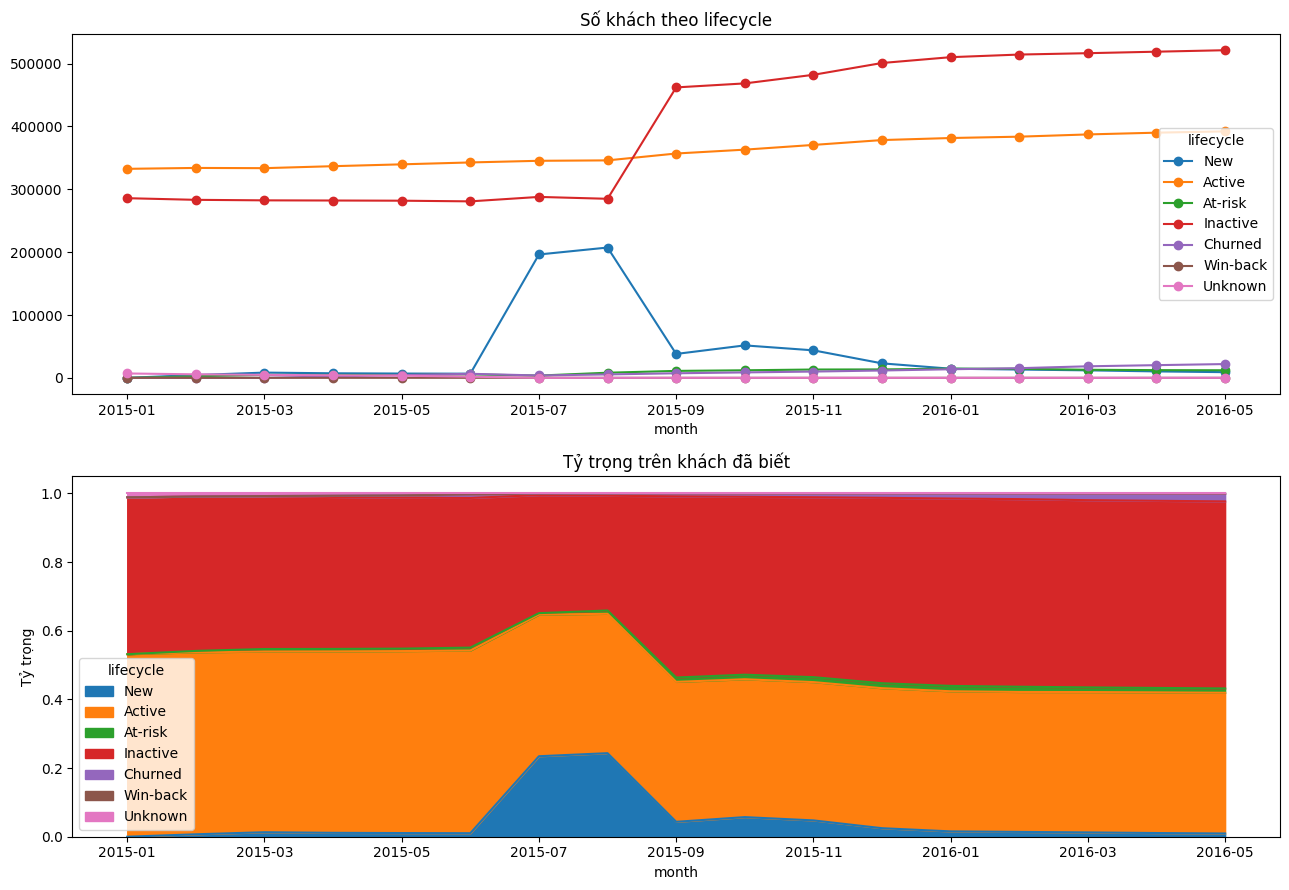

,lifecycle,n_customers,share
0,New,9032,0.94%
1,Active,392211,41.00%
2,At-risk,12050,1.26%
3,Inactive,521386,54.50%
4,Churned,21933,2.29%
5,Win-back,33,0.00%
6,Unknown,0,0.00%


In [12]:
order = ['New','Active','At-risk','Inactive','Churned','Win-back','Unknown']
pop = tables['population'].groupby(['month','lifecycle'], observed=True).n.sum().unstack(fill_value=0).reindex(columns=order,fill_value=0)
share = pop.div(pop.sum(axis=1),axis=0)
fig, ax = plt.subplots(2,1,figsize=(13,9))
pop.plot(ax=ax[0],marker='o',title='Số khách theo lifecycle')
share.plot.area(ax=ax[1],title='Tỷ trọng trên khách đã biết'); ax[1].set_ylabel('Tỷ trọng')
plt.tight_layout(); plt.show()
latest_population = pop.iloc[-1].rename('n_customers').to_frame()
latest_population['share'] = latest_population.n_customers/latest_population.n_customers.sum()
show_compact(latest_population.reset_index(),pct=['share'])
if SHOW_DETAILS:
    display(pop); display(tables['entries'])


**Nhận xét — snapshot 01/2015–05/2016:**

Tháng cuối có 392.211 Active và 521.386 Inactive. Bước tăng Inactive tháng 9 cần đọc cùng cohort July: 193.115 khách xuất hiện lần đầu tháng 7 hết cửa sổ New. Nhãn đổi do hết cửa sổ không đồng nghĩa hành vi vừa thay đổi.


## 4. Ma trận chuyển và xu hướng từng đường chuyển
Ma trận pooled có trọng số **customer-month**, không phải xác suất trên khách duy nhất; khách có lịch sử dài đóng góp nhiều lần. Ô trống nguồn = chưa có mẫu, không phải xác suất 0. Ma trận “chỉ đổi trạng thái” có mẫu số khác và chỉ dùng để xem điểm đến khi đã rời trạng thái.

Ma trận count chỉ hiển thị ở mục toàn kỳ phía dưới để tránh lặp.


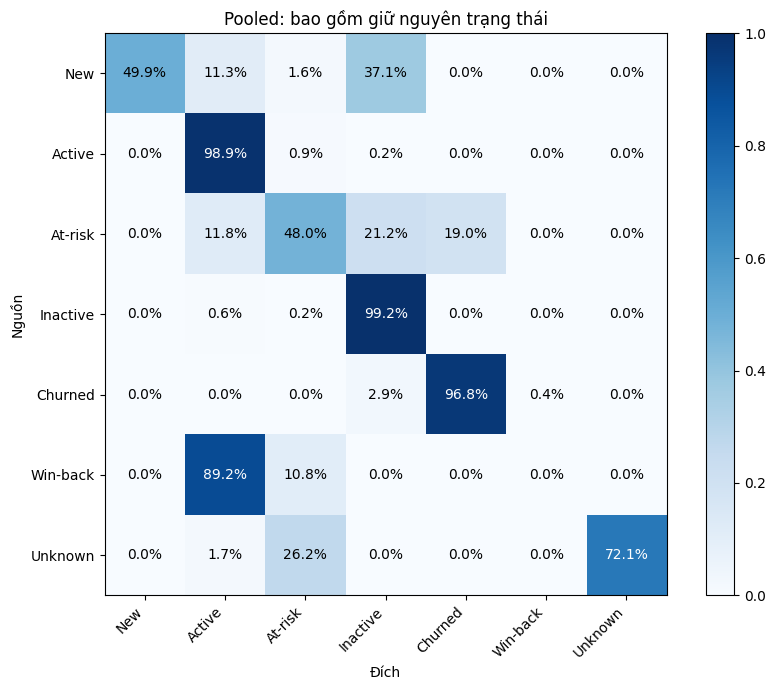

In [13]:
tr = tables['transitions']
def matrix(df, changes_only=False):
    d = df[df.previous_lifecycle != df.lifecycle] if changes_only else df
    n = d.groupby(['previous_lifecycle','lifecycle'],observed=True).n.sum().unstack(fill_value=0).reindex(index=order,columns=order,fill_value=0)
    return n, n.div(n.sum(axis=1).replace(0,np.nan),axis=0)
def heatmap(a,title):
    fig, ax = plt.subplots(figsize=(9,7))
    im=ax.imshow(a.to_numpy(float),vmin=0,vmax=1,cmap='Blues')
    ax.set_xticks(range(len(order)),order,rotation=45,ha='right'); ax.set_yticks(range(len(order)),order)
    for i in range(len(order)):
        for k in range(len(order)):
            v=a.iloc[i,k]
            ax.text(k,i,'—' if pd.isna(v) else f'{v:.1%}',ha='center',va='center',color='white' if pd.notna(v) and v>.5 else 'black')
    ax.set_xlabel('Đích'); ax.set_ylabel('Nguồn'); ax.set_title(title); fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
n,p = matrix(tr); heatmap(p,'Pooled: bao gồm giữ nguyên trạng thái')
if SHOW_DETAILS:
    _,p_change=matrix(tr,True); heatmap(p_change,'Điểm đến có điều kiện đã đổi trạng thái')
for month in sorted(tr.month.unique()):
    _, p_month = matrix(tr[tr.month==month])
    p_month.to_csv(OUTPUT_DIR / f'transition_rates_{month}.csv')
if SHOW_DETAILS:
    # Chọn tháng muốn xem chi tiết
    MONTH_TO_VIEW = END_MONTH
    _,p_month=matrix(tr[tr.month==MONTH_TO_VIEW]); heatmap(p_month,f'Tháng đích {MONTH_TO_VIEW}')
    paths=[('New','Active'),('New','Inactive'),('Active','At-risk'),('At-risk','Active'),('At-risk','Inactive'),('At-risk','Churned'),('Inactive','Active'),('Churned','Win-back')]
    fig,axs=plt.subplots(4,2,figsize=(14,13))
    months=sorted(tr.month.unique())
    for ax,(s,t) in zip(axs.flat,paths):
        den=tr[tr.previous_lifecycle==s].groupby('month',observed=True).n.sum().reindex(months)
        num=tr[(tr.previous_lifecycle==s)&(tr.lifecycle==t)].groupby('month',observed=True).n.sum().reindex(months,fill_value=0)
        (num/den.replace(0,np.nan)).plot(ax=ax,marker='o',title=f'{s} → {t}')
        ax.set_ylabel('Tỷ lệ / trạng thái nguồn'); ax.tick_params(axis='x',rotation=45)
    plt.tight_layout(); plt.show()


**Nhận xét — snapshot 01/2015–05/2016:**

Mỗi hàng của ma trận tỷ lệ chia trên toàn bộ lượt có trạng thái nguồn đó, kể cả giữ nguyên. Active→Active là 98,86%, Inactive→Inactive là 99,23%. Đây là độ ổn định theo tháng; không phải tỷ lệ khách giữ nguyên toàn bộ 17 tháng.


### Ma trận số lượt chuyển trạng thái toàn kỳ
Mỗi cặp tháng liên tiếp của một khách đã biết đóng góp **1 lượt**, kể cả giữ nguyên trạng thái. Một khách có dòng panel đủ 17 tháng đóng góp 16 lượt. Khách vào panel muộn đóng góp ít hơn; tháng đầu của khách là entry, không phải một lượt chuyển. Dòng vắng snapshot có nhãn At-risk/Churned vẫn được tính nếu input RFM giữ dòng khách đó.

Đây là lượt chuyển lifecycle, **khác acquisition event** (0→1 sản phẩm). Tổng trên ma trận là số lượt customer-month, không phải số khách duy nhất. Khách có thể đóng góp nhiều lần vào cùng một ô.


In [14]:
n_all, _ = matrix(tr)
n_all.index.name = 'from_state'; n_all.columns.name = 'to_state'
steps = int(n_all.to_numpy().sum())
stays = int(np.trace(n_all.to_numpy()))
summary = pd.DataFrame([{
    'unique_customers': len(customer_step_counts),
    'all_transition_steps': steps,
    'same_state_steps': stays,
    'changed_state_steps': steps-stays,
    'mean_steps_per_customer': customer_step_counts.mean(),
}])
assert steps == int(customer_step_counts.sum())
display(summary)
display(n_all)
if SHOW_DETAILS:
    fig, ax = plt.subplots(figsize=(11,8))
    im = ax.imshow(n_all.to_numpy(), cmap='Blues')
    ax.set_xticks(range(len(order)), order, rotation=45, ha='right')
    ax.set_yticks(range(len(order)), order)
    peak = n_all.to_numpy().max()
    for i in range(len(order)):
        for k in range(len(order)):
            v = int(n_all.iloc[i,k])
            ax.text(k,i,f'{v:,}',ha='center',va='center',fontsize=9,
                    color='white' if v > peak*.5 else 'black')
    ax.set(xlabel='Trạng thái tháng t+1',ylabel='Trạng thái tháng t',
           title=f'Ma trận số lượt toàn kỳ — {steps:,} lượt; bao gồm giữ nguyên trạng thái')
    fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()
pairs = n_all.stack().rename('n_steps').reset_index()
pairs['share_of_all_steps'] = pairs.n_steps / steps if steps else np.nan
pairs = pairs.sort_values('n_steps',ascending=False)
if SHOW_DETAILS: display(pairs[pairs.n_steps>0])
contribution = customer_step_counts.value_counts().sort_index().rename_axis('n_transitions').rename('n_customers').to_frame()
contribution['total_steps'] = contribution.index * contribution.n_customers
if SHOW_DETAILS: display(contribution)
n_all.to_csv(OUTPUT_DIR / 'transition_matrix_counts_full_period.csv')
summary.to_csv(OUTPUT_DIR / 'transition_totals.csv',index=False)
pairs.to_csv(OUTPUT_DIR / 'transition_pairs_full_period.csv',index=False)
contribution.to_csv(OUTPUT_DIR / 'transition_contribution_distribution.csv')
if SHOW_DETAILS: fig.savefig(OUTPUT_DIR / 'transition_matrix_counts_full_period.png',dpi=160,bbox_inches='tight')


,unique_customers,all_transition_steps,same_state_steps,changed_state_steps,mean_steps_per_customer
0,956645,12902926,12383853,519073,13.487685


to_state,New,Active,At-risk,Inactive,Churned,Win-back,Unknown
from_state,,,,,,,
New,321368,72842,10341,238867,0,0,106
Active,0,5658003,53127,11877,0,0,371
At-risk,0,16213,66067,29169,26065,0,10
Inactive,0,35054,13003,6195912,0,0,0
Churned,0,0,0,3643,123297,487,2
Win-back,0,405,49,0,0,0,0
Unknown,0,455,6987,0,0,0,19206


**Nhận xét — snapshot 01/2015–05/2016:**

Tổng 12.902.926 lượt, trong đó 12.383.853 giữ nguyên (95,98%) và 519.073 đổi nhãn (4,02%). Một khách có thể đóng góp nhiều lượt vào cùng ô. Khách xuất hiện muộn có ít hơn 16 lượt; 4.693 khách tháng cuối đóng góp 0 lượt. Bản phân bố đóng góp đầy đủ vẫn xuất CSV.


## 5. Hai loại At-risk và kết quả sau 1/3 tháng
Không gộp vắng panel với giảm cờ active. Chỉ có các mốc t còn đủ h tháng đến cuối dataset. Đây là kết quả theo rule hiện tại, không phải đánh giá dự báo hay xác nhận churn thật.
Bỏ top30 đếm theo tháng vì phụ thuộc quy mô nguồn; kết quả cũ lưu trong lifecycle-eda-report.md.


In [15]:
rt=tables['reason_transitions']
hz=tables['horizons']
for h in ([1,3] if SHOW_DETAILS else [3]):
    q=hz[(hz.horizon==h)&(hz.source_lifecycle=='At-risk')]
    z=q.groupby(['source_reason','lifecycle'],observed=True).n.sum().unstack(fill_value=0)
    summary=z.div(z.sum(axis=1).replace(0,np.nan),axis=0)
    summary.insert(0,'n_origins',z.sum(axis=1))
    print('Trạng thái tại t+',h)
    show_compact(summary.reset_index(),pct=list(z.columns))


Trạng thái tại t+ 3


lifecycle,source_reason,n_origins,Churned,Win-back,At-risk,Active,Inactive,Unknown
0,short_panel_absence,52403,80.69%,0.52%,1.02%,2.86%,14.91%,0.01%
1,recent_active_drop,59989,4.60%,0.00%,6.93%,26.23%,62.23%,0.00%


**Nhận xét — snapshot 01/2015–05/2016:**

Hai loại At-risk có đường đi khác nhau: nhánh vắng panel sau 3 tháng có 80,69% Churned; nhánh giảm cờ active có 62,23% Inactive và 26,23% Active. Churned cao ở nhánh vắng chịu ảnh hưởng định nghĩa vắng ≥3 tháng. Đây là endpoint t+3, không phải đã từng quay lại trong 3 tháng.


## 6. Quay lại sau khi vắng và hành vi ở từng trạng thái
Phân biệt gap 1, 2, 3+; quay lại snapshot chưa chắc Active. Chỉ tính acquisition/drop khi có cặp đủ điều kiện. M_n_products là độ rộng danh mục, không phải giá trị tiền.
Phần hành vi cùng tháng chỉ hiển thị drop và portfolio; acquisition cùng tháng phụ thuộc trực tiếp rule, xem hành vi tương lai để kiểm chứng.


In [16]:
ret=tables['returns']
if not ret.empty:
    z=ret.groupby(['gap_group','lifecycle'],observed=True).n.sum().unstack(fill_value=0)
    summary=z.div(z.sum(axis=1),axis=0)
    summary.insert(0,'n_returns',z.sum(axis=1))
    show_compact(summary.reset_index(),pct=list(z.columns))


lifecycle,gap_group,n_returns,Win-back,Active,Inactive,Unknown
0,1 month,2359,0.00%,25.73%,73.89%,0.38%
1,2 months,1752,0.00%,15.18%,84.76%,0.06%
2,3+ months,4132,11.79%,0.00%,88.17%,0.05%


**Nhận xét — snapshot 01/2015–05/2016:**

Trong các lượt quay lại sau gap ≥3 tháng, 487/4.132 (11,79%) là Win-back và 3.643/4.132 (88,17%) là Inactive. Có lại snapshot không đồng nghĩa hồi phục hoạt động. Bảng này chỉ xét lượt quay lại đã xảy ra, không đo xác suất quay lại của mọi đợt vắng.


### 6.1. Lifecycle × biến động danh mục — toàn kỳ và từng tháng
Giữ nguyên lifecycle-v1. `portfolio_transition` là hành vi giữa hai tháng, đặt bên cạnh trạng thái lifecycle ở tháng đích.

| Nhóm | Điều kiện |
|---|---|
| Increase | Acquisition >0 và drop=0 |
| Decrease | Acquisition=0 và drop>0 |
| Mixed | Acquisition >0 và drop>0; tổng danh mục có thể tăng, giảm hoặc không đổi |
| Maintain | Acquisition=0 và drop=0; tách riêng 0→0 với danh mục dương |
| Unknown | Không đủ cặp snapshot/danh mục để so sánh; không coi là Maintain |

Bảng count bao gồm Unknown trên **toàn bộ khách đã biết**. Tỷ lệ Increase/Decrease/Mixed/Maintain chỉ chia trên cặp `portfolio_comparable=True`. Báo coverage trên toàn bộ nhóm và trên các snapshot observed. Các số toàn kỳ là **lượt khách–tháng**, không phải khách duy nhất. Nhóm không có cặp comparable giữ tỷ lệ NA.

Theo rule v1, acquisition xác nhận có thể làm khách thành Active (trừ nhãn ưu tiên), nên bảng cùng tháng là mô tả, không dùng chứng minh lifecycle độc lập dự đoán acquisition. At-risk tách thêm theo reason để tránh trộn vắng panel và giảm cờ active.


In [17]:
PORT_ORDER = ['Increase','Decrease','Mixed','Maintain','Unknown']
KNOWN_PORT = PORT_ORDER[:-1]
portfolio_counts = tables['lifecycle_portfolio']

def portfolio_summary(data, keys):
    q = data.groupby(keys+['portfolio_transition'], observed=True, dropna=False).n.sum().unstack(fill_value=0)
    q = q.reindex(columns=PORT_ORDER,fill_value=0)
    total = q.sum(axis=1)
    eligible = q[KNOWN_PORT].sum(axis=1)
    observed = data[data.is_observed].groupby(keys, observed=True, dropna=False).n.sum().reindex(q.index,fill_value=0)
    coverage = pd.DataFrame({'n_customer_months':total,'n_observed':observed,
        'n_comparable':eligible,'n_unknown':q.Unknown,
        'coverage_all':eligible/total.replace(0,np.nan),
        'coverage_observed':eligible/observed.replace(0,np.nan)})
    shares = q[KNOWN_PORT].div(eligible.replace(0,np.nan),axis=0)
    return q, shares, coverage

portfolio_all, portfolio_all_shares, portfolio_all_coverage = portfolio_summary(portfolio_counts,['lifecycle'])
portfolio_all = portfolio_all.reindex(order,fill_value=0)
portfolio_all_shares = portfolio_all_shares.reindex(order)
portfolio_all_coverage = portfolio_all_coverage.reindex(order)
portfolio_main = portfolio_all_coverage[['n_customer_months','n_comparable','coverage_all']].join(portfolio_all_shares)
show_compact(portfolio_main.reset_index(),pct=['coverage_all']+KNOWN_PORT,
             labels={'n_customer_months':'N lượt','n_comparable':'N đủ dữ liệu','coverage_all':'Coverage'})
if SHOW_DETAILS:
    display(portfolio_all); display(portfolio_all_coverage)
portfolio_month, portfolio_month_shares, portfolio_month_coverage = portfolio_summary(portfolio_counts,['month','lifecycle'])
for name, df in [('lifecycle_portfolio_counts_full_period',portfolio_all),
                 ('lifecycle_portfolio_shares_eligible_full_period',portfolio_all_shares),
                 ('lifecycle_portfolio_coverage_full_period',portfolio_all_coverage),
                 ('lifecycle_portfolio_counts_by_month',portfolio_month),
                 ('lifecycle_portfolio_shares_eligible_by_month',portfolio_month_shares),
                 ('lifecycle_portfolio_coverage_by_month',portfolio_month_coverage)]:
    df.to_csv(OUTPUT_DIR/f'{name}.csv')

if SHOW_DETAILS:
    PORT_MONTH_TO_VIEW = END_MONTH
    print('Tháng:',PORT_MONTH_TO_VIEW)
    display(portfolio_month.xs(PORT_MONTH_TO_VIEW,level='month').reindex(order,fill_value=0))
    display(portfolio_month_coverage.xs(PORT_MONTH_TO_VIEW,level='month').reindex(order))
    display(portfolio_month_shares.xs(PORT_MONTH_TO_VIEW,level='month').reindex(order)*100)
    
    fig,ax = plt.subplots(figsize=(10,5))
    a = portfolio_all_shares.dropna(how='all')
    if not a.empty:
        a.plot.bar(stacked=True,ax=ax)
        ax.set(title='Lifecycle × biến động danh mục toàn kỳ — chỉ cặp comparable',
               ylabel='Tỷ lệ',xlabel='Lifecycle tháng đích')
        ax.tick_params(axis='x',rotation=30)
        plt.tight_layout(); plt.show()
    else:
        plt.close(fig); print('Không có cặp comparable để vẽ.')


,lifecycle,N lượt,N đủ dữ liệu,Coverage,Increase,Decrease,Mixed,Maintain
0,New,652556,321261,49.23%,7.76%,0.74%,1.35%,90.15%
1,Active,6115589,5781911,94.54%,5.83%,5.31%,1.39%,87.47%
2,At-risk,149574,86674,57.95%,0.00%,22.22%,0.00%,77.78%
3,Inactive,6765355,6472556,95.67%,0.00%,0.34%,0.00%,99.66%
4,Churned,149362,0,0.00%,NA,NA,NA,NA
5,Win-back,487,0,0.00%,NA,NA,NA,NA
6,Unknown,26648,7182,26.95%,0.00%,13.12%,0.00%,86.88%


**Nhận xét — snapshot 01/2015–05/2016:**

Trên cặp đủ dữ liệu, Active có 87,47% Maintain, 5,83% Increase, 5,31% Decrease, 1,39% Mixed. Inactive có 99,66% Maintain. Nhánh At-risk đủ quan sát có 22,22% Decrease. Coverage New chỉ 49,23%, vì nhiều lượt là tháng đầu của khách; Churned/Win-back không có cặp portfolio so sánh nên tỷ lệ là NA. Increase/Mixed bằng 0 ở Inactive một phần do rule acquisition→Active, không chứng minh khách inactive không thể thêm sản phẩm.


### 6.2. Biến động theo tháng, At-risk reason và Maintain 0→0
Biểu đồ tỷ lệ chỉ dùng cặp comparable; xem coverage phía dưới để tránh diễn giải thay đổi do thiếu quan sát. Churned/Win-back thường không có cặp comparable vì một trong hai tháng vắng.

Maintain 0→0 khác duy trì một danh mục dương. Bảng At-risk reason chỉ mô tả khác biệt bằng chứng; không suy ra drop gây giảm active. Đây không phải ma trận chuyển giữa hai lifecycle — đó là bảng đã có ở mục 4.


In [18]:
if SHOW_DETAILS:
    fig,axs = plt.subplots(4,2,figsize=(14,14))
    for ax,life in zip(axs.flat,order):
        if life not in portfolio_month_shares.index.get_level_values('lifecycle'):
            ax.set_visible(False); continue
        g = portfolio_month_shares.xs(life,level='lifecycle').sort_index()
        if g.notna().any().any():
            g.plot.bar(stacked=True,ax=ax,legend=False)
            ax.set_title(str(life)); ax.set_ylabel('Tỷ lệ / comparable')
            ax.tick_params(axis='x',rotation=60,labelsize=8)
        else:
            ax.text(.5,.5,f'{life}: không có cặp comparable',ha='center',va='center',transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
    axs.flat[-1].set_visible(False)
    handles,labels = next(((ax.get_legend_handles_labels()) for ax in axs.flat if ax.get_legend_handles_labels()[0]),([],[]))
    if handles: fig.legend(handles,labels,loc='upper center',ncol=4)
    plt.tight_layout(rect=[0,0,1,.96]); plt.show()
    coverage_plot = portfolio_month_coverage.coverage_all.unstack('lifecycle').reindex(columns=order).sort_index()
    coverage_plot.index = pd.to_datetime(coverage_plot.index)
    coverage_plot.plot(figsize=(12,4),marker='o',title='Coverage portfolio-comparable / toàn bộ nhóm theo tháng')
    plt.ylabel('Tỷ lệ'); plt.tight_layout(); plt.show()
    
at_risk_data = portfolio_counts[portfolio_counts.lifecycle=='At-risk']
risk_counts,risk_shares,risk_coverage = portfolio_summary(at_risk_data,['lifecycle_reason'])
print('At-risk theo lý do — count, coverage, tỷ lệ eligible (%)')
risk_main = risk_coverage[['n_customer_months','n_comparable','coverage_all']].join(risk_shares[['Decrease','Maintain']])
show_compact(risk_main.reset_index(),pct=['coverage_all','Decrease','Maintain'])
if SHOW_DETAILS: display(risk_counts)
risk_counts.to_csv(OUTPUT_DIR/'at_risk_reason_portfolio_counts.csv')
risk_coverage.to_csv(OUTPUT_DIR/'at_risk_reason_portfolio_coverage.csv')
risk_shares.to_csv(OUTPUT_DIR/'at_risk_reason_portfolio_shares_eligible.csv')

maintain_data = portfolio_counts[portfolio_counts.portfolio_transition=='Maintain']
if not maintain_data.empty:
    maintain_split = maintain_data.groupby(['lifecycle','portfolio_detail'],observed=True).n.sum().unstack(fill_value=0)
    maintain_split = maintain_split.reindex(index=order,columns=['Maintain_zero','Maintain_positive'],fill_value=0)
    maintain_split['n_maintain'] = maintain_split[['Maintain_zero','Maintain_positive']].sum(axis=1)
    maintain_split['share_zero_within_maintain'] = maintain_split.Maintain_zero/maintain_split.n_maintain.replace(0,np.nan)
    show_compact(maintain_split.reset_index(),pct=['share_zero_within_maintain'])
    maintain_split.to_csv(OUTPUT_DIR/'maintain_zero_vs_positive_by_lifecycle.csv')

# Đối soát: mỗi khách–tháng góp đúng một portfolio category.
expected = tables['population'].groupby('month',observed=True).n.sum().sort_index()
actual = portfolio_counts.groupby('month',observed=True).n.sum().sort_index()
pd.testing.assert_series_equal(actual,expected,check_names=False)
assert portfolio_counts.loc[portfolio_counts.portfolio_comparable,'portfolio_transition'].ne('Unknown').all()
assert portfolio_counts.loc[~portfolio_counts.portfolio_comparable,'portfolio_transition'].eq('Unknown').all()
assert np.allclose(portfolio_all_shares.dropna(how='all').sum(axis=1),1)
print('Portfolio EDA đối soát đạt. Rule lifecycle không đổi.')


At-risk theo lý do — count, coverage, tỷ lệ eligible (%)


,lifecycle_reason,n_customer_months,n_comparable,coverage_all,Decrease,Maintain
0,short_panel_absence,62900,0,0.00%,NA,NA
1,recent_active_drop,86674,86674,100.00%,22.22%,77.78%


portfolio_detail,lifecycle,Maintain_zero,Maintain_positive,n_maintain,share_zero_within_maintain
0,New,207833,81791,289624,71.76%
1,Active,8926,5048506,5057432,0.18%
2,At-risk,15420,51994,67414,22.87%
3,Inactive,2024726,4426080,6450806,31.39%
4,Churned,0,0,0,NA
5,Win-back,0,0,0,NA
6,Unknown,583,5657,6240,9.34%


Portfolio EDA đối soát đạt. Rule lifecycle không đổi.


**Nhận xét — snapshot 01/2015–05/2016:**

At-risk do vắng có 0 cặp comparable; tỷ lệ Decrease của nhánh đó là NA, không phải 0%. At-risk do giảm active có đủ 86.674 cặp, trong đó 19.260 Decrease (22,22%). Trong Maintain của Inactive, 31,39% là 0→0; 68,61% còn danh mục dương. Vì vậy Inactive không đồng nghĩa không có sản phẩm, và Maintain không đồng nghĩa duy trì một danh mục đang có. Không suy ra drop gây inactive từ bảng cùng tháng.


## 7. Thời gian giữ trạng thái — spell
Một khách có thể có nhiều spell cùng trạng thái. `left_censored=True`: spell có từ đầu dataset, chưa biết bắt đầu thật. `right_censored=True`: chưa kết thúc ở cuối kỳ. Bảng duration dưới tách censoring; **không lấy trung bình spell đã kết thúc làm thời gian điển hình của toàn bộ khách**. Survival mô tả bên dưới dùng spell không left-censored, vẫn giữ right-censored; chưa điều chỉnh khách đóng góp nhiều spell.

Survival chỉ vẽ ngoài New/Win-back, vì duration của hai nhãn này chủ yếu do cửa sổ rule. Bảng spell vẫn giữ đầy đủ.


In [19]:
sp=tables['spells']
if SHOW_DETAILS:
    display(sp.groupby(['lifecycle','left_censored','right_censored'],observed=True).n.sum().unstack(fill_value=0))
    fig,ax=plt.subplots(figsize=(12,6))
    for life in [x for x in order if x not in ['New','Win-back']]:
        d=sp[(sp.lifecycle==life)&~sp.left_censored]
        if d.empty: continue
        surv=1.; xs=[0]; ys=[1.]
        for age in sorted(d.duration.unique()):
            risk=d.loc[d.duration>=age,'n'].sum()
            exits=d.loc[(d.duration==age)&~d.right_censored,'n'].sum()
            surv*=1-exits/risk
            xs.append(age); ys.append(surv)
        ax.step(xs,ys,where='post',label=life)
    ax.set(xlabel='Số tháng trong spell',ylabel='P(spell chưa kết thúc)',title='Survival của spell: loại left-censored, giữ right-censored')
    ax.legend(); plt.tight_layout(); plt.show()


**Nhận xét — snapshot 01/2015–05/2016:**

Spell đã được tính và vẫn xuất CSV. Phân tích survival/spell ít giúp lựa chọn rule ở màn hình chính vì Active/Inactive persistence đã thấy trong ma trận, còn thời gian New/Win-back do thiết kế; chi tiết và kết quả gốc được giữ trong báo cáo Markdown.


## 8. Cohort mới xuất hiện và lịch sử mẫu để audit
Cohort tháng đầu là left-censored, tách khỏi cohort mới. So sánh theo tuổi quan sát với cùng độ dài follow-up. Không xếp hạng đường đi nén từ mẫu ID; lịch sử mẫu chỉ để đối chiếu rule từng khách.


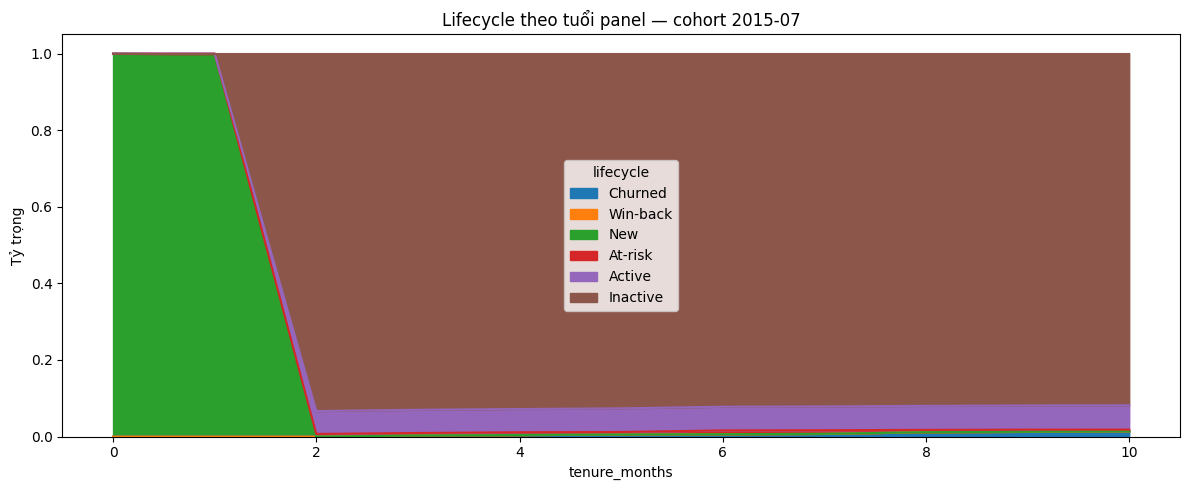

In [20]:
co=tables['cohorts']
COHORT_TO_VIEW='2015-07'
z=co[(co.cohort==COHORT_TO_VIEW)&~co.is_left_censored].groupby(['tenure_months','lifecycle'],observed=True).n.sum().unstack(fill_value=0)
if not z.empty:
    z.div(z.sum(axis=1),axis=0).plot.area(figsize=(12,5),title=f'Lifecycle theo tuổi panel — cohort {COHORT_TO_VIEW}')
    plt.ylabel('Tỷ trọng'); plt.tight_layout(); plt.show()
hist=history_sample.sort_values(['customer_id','as_of_month'])
if SHOW_DETAILS:
    # Điền ID từ history_sample để xem lịch sử từng khách
    CUSTOMER_ID = int(hist.customer_id.iloc[0]) if len(hist) else None
    cols=['customer_id','as_of_month','lifecycle','lifecycle_reason','is_observed','is_active','months_since_last_seen',
          'n_acquisitions_month','n_drops_month','portfolio_transition','M_n_products','months_in_state']
    display(hist.loc[hist.customer_id==CUSTOMER_ID,cols])


**Nhận xét — snapshot 01/2015–05/2016:**

Cohort July chủ yếu chuyển New→Inactive ở tuổi panel 2 và duy trì Inactive sau đó; đây là mô tả trên biểu đồ, không đặt tỷ lệ cohort chính xác khi chưa có bảng số. New là mới trong panel, chưa xác nhận mới đăng ký ngân hàng. Lịch sử từng khách chỉ phục vụ audit và được mở bằng SHOW_DETAILS.


## 9. Đối soát và ghi nhận kết luận
Kiểm tra bảo toàn luồng: khách hiện tại = tổng transition + entry; số nguồn transition = số khách tháng trước. Bước kiểm này tránh diễn giải entry là chuyển trạng thái. Khi đọc kết quả, ghi số lượng và mẫu số bên cạnh tỷ lệ, nhất là Win-back có thể rất ít khách.


In [21]:
monthly=pop.sum(axis=1)
flows=tr.groupby('month',observed=True).n.sum().reindex(monthly.index,fill_value=0)
entries=tables['entries'].groupby('month',observed=True).n.sum().reindex(monthly.index,fill_value=0)
assert (flows+entries==monthly).all(), 'Transition + entry không khớp population'
assert np.array_equal(flows.iloc[1:].to_numpy(),monthly.iloc[:-1].to_numpy()), 'Mẫu số nguồn không khớp tháng trước'
assert (tr.groupby(['month','previous_lifecycle'],observed=True).rate.sum().sub(1).abs()<1e-9).all()
if SHOW_DETAILS: display(pd.DataFrame({'known_customers':monthly,'transitions_including_stay':flows,'entries':entries}))
print('Đối soát luồng đạt. EDA outputs:', OUTPUT_DIR.resolve())


Đối soát luồng đạt. EDA outputs: /kaggle/working/lifecycle_eda


**Nhận xét — snapshot 01/2015–05/2016:**

Các kiểm tra bảo toàn luồng đều đạt: transition+entry bằng population, số nguồn bằng population tháng trước và tỷ lệ mỗi hàng nguồn bằng 1. Điều này kiểm chứng số đếm, không xác nhận mọi nhãn đúng nghiệp vụ.


### Những câu hỏi để kết luận sau khi chạy
- New hết cửa sổ 2 tháng đi tới đâu? Tách cohort July 2015 và cohort nhỏ khác.
- Active ổn định bao nhiêu? At-risk đến từ vắng snapshot hay active 1→0?
- At-risk ngắn hạn hồi phục thế nào so với At-risk do active giảm, sau 1 và 3 tháng?
- Churned quay lại thành Win-back, Inactive hay Unknown? Có đủ mẫu để diễn giải không?
- Chuyển trạng thái tập trung ở tháng nào, có trùng entry lớn/hết cửa sổ rule không?
- Khách giữ sản phẩm nhưng Inactive có nhiều không? Acquisition/drop có khác nhau giữa trạng thái không?

**Giới hạn đầu vào:** RFM aggregate cho biết số drop có điều kiện; không xác định sản phẩm nào bị bỏ, nguyên nhân hết hạn, giao dịch thực tế hay churn ngân hàng. Muốn EDA tên sản phẩm bị drop cần cờ sở hữu 24 sản phẩm từng tháng. Các mốc 2/3/2 tạo một số chuyển trạng thái theo thiết kế; EDA mô tả chúng chứ chưa chứng minh threshold là tối ưu.

Notebook chỉ tạo bảng EDA và lịch sử mẫu; không lưu full customer-month lifecycle, không thêm CLV/RFM segmentation/affinity.


## 10. EDA bổ sung để xem xét rule lifecycle
**Rule vẫn giữ nguyên.** Phần này đọc lại RFM một lượt, dùng code `process_month` phía trên và chỉ lưu bảng tổng hợp. Run All để có cả kết quả cũ và mới; các output có sẵn ở mục 1–9 là kết quả lần chạy bạn gửi, phần bổ sung chưa chạy trên Parquet thật tại thời điểm chỉnh file.

Ba quyết định cần bằng chứng: (1) Active chỉ do acquisition có duy trì hoạt động không; (2) active 1→0 hồi phục sau bao lâu; (3) gap bao nhiêu tháng thì khả năng quay lại giảm. Kết quả tương lai không dùng để gán lại nhãn ở quá khứ.

**Phân biệt hai kết quả:** `at_h` là tại đúng t+h; `within_h` là đã từng xảy ra trong t+1…t+h. Thiếu snapshot không gán acquisition/drop bằng 0: báo coverage riêng. Số lượt là customer-origin-month, một khách có thể xuất hiện nhiều mốc; không coi là các mẫu độc lập.


In [22]:
FOLLOWUP_H = [1, 2, 3, 6]
MIN_ORIGINS = 100  # chỉ gắn cờ ít mẫu, không thay rule

def rule_review_origin(out, cumulative):
    z = out[['customer_id','lifecycle','lifecycle_reason','is_observed','months_since_last_seen',
             'months_since_active_drop','first_seen_month','is_left_censored']].copy()
    z = z.rename(columns={'lifecycle':'source_lifecycle','lifecycle_reason':'source_reason',
                          'is_observed':'source_observed'})
    z['gap_at_origin'] = z.months_since_last_seen.clip(upper=6).astype('int8')
    z['drop_age_at_origin'] = z.months_since_active_drop.fillna(-1).clip(upper=6).astype('int8')
    z['cohort'] = z.first_seen_month.dt.strftime('%Y-%m')
    z = z.drop(columns=['months_since_last_seen','months_since_active_drop','first_seen_month'])
    return z.join(cumulative, on='customer_id')

REVIEW_KEYS = ['source_lifecycle','source_reason','source_observed','gap_at_origin',
               'drop_age_at_origin','cohort','is_left_censored']
REVIEW_SUMS = ['n_origins','observed_at_h','active_known_at_h','active_flag_at_h',
              'active_flag_within_h','observed_within_h','acq_eligible_at_h','acq_at_h',
              'acq_within_h','drop_eligible_at_h','drop_at_h','still_same_lifecycle_at_h']

def rule_review_followup(origin, out, cumulative, h, origin_month):
    future = out[['customer_id','lifecycle','is_observed','is_active','has_acquisition_month','n_drops_month']]
    z = origin.merge(future, on='customer_id', how='left', validate='one_to_one')
    if z.lifecycle.isna().any(): raise ValueError('Khách đã biết mất dòng panel.')
    z = z.join(cumulative.rename(columns=lambda c: 'future_'+c), on='customer_id')
    z['n_origins'] = 1
    z['observed_at_h'] = z.is_observed.astype(int)
    z['active_known_at_h'] = (z.is_observed & z.is_active.isin([0,1])).astype(int)
    z['active_flag_at_h'] = (z.is_observed & z.is_active.eq(1)).astype(int)
    z['active_flag_within_h'] = (z.future_cum_active > z.cum_active).astype(int)
    z['observed_within_h'] = (z.future_cum_observed > z.cum_observed).astype(int)
    z['acq_eligible_at_h'] = z.has_acquisition_month.notna().astype(int)
    z['acq_at_h'] = z.has_acquisition_month.fillna(False).astype(int)
    z['acq_within_h'] = (z.future_cum_acq > z.cum_acq).astype(int)
    z['drop_eligible_at_h'] = z.n_drops_month.notna().astype(int)
    z['drop_at_h'] = z.n_drops_month.gt(0).fillna(False).astype(int)
    z['still_same_lifecycle_at_h'] = z.lifecycle.eq(z.source_lifecycle).astype(int)
    q = z.groupby(REVIEW_KEYS, observed=True, dropna=False)[REVIEW_SUMS].sum().reset_index()
    q.insert(0,'origin_month',origin_month); q.insert(1,'horizon',h)
    return q

review_parts = []
review_ring = {}
cumulative = pd.DataFrame(columns=['cum_observed','cum_active','cum_acq'],dtype='int32')
review_state = review_prev = None
for m in range(cfg.start_idx,cfg.end_idx+1):
    cur = read_month(feat_dir,m)
    issues,_ = validate_month(cur,review_prev,m,cfg)
    if any(x['severity']=='fatal' for x in issues): raise InputValidationError(str(issues))
    out,review_state = process_month(cur,review_state,cfg)
    if out.data_issue.notna().any(): raise InputValidationError('data_issue trong EDA bổ sung')
    cumulative = cumulative.reindex(out.customer_id.to_numpy(),fill_value=0)
    cumulative.index.name = 'customer_id'
    cumulative['cum_observed'] += out.is_observed.to_numpy(dtype='int32')
    cumulative['cum_active'] += (out.is_observed & out.is_active.eq(1)).to_numpy(dtype='int32')
    cumulative['cum_acq'] += out.has_acquisition_month.fillna(False).to_numpy(dtype='int32')
    for h in FOLLOWUP_H:
        if m-h in review_ring:
            review_parts.append(rule_review_followup(review_ring[m-h],out,cumulative,h,fmt_month(m-h)))
    review_ring[m] = rule_review_origin(out,cumulative)
    for k in list(review_ring):
        if k < m-max(FOLLOWUP_H)+1: del review_ring[k]
    review_prev = cur[CORE_COLS + [c for c in AUX_COLS if c in cur.columns]]
    print('Rule-review EDA:',fmt_month(m))
review = pd.concat(review_parts,ignore_index=True)
review.to_csv(OUTPUT_DIR/'rule_review_followup_by_month_cohort.csv',index=False)


Rule-review EDA: 2015-01
Rule-review EDA: 2015-02
Rule-review EDA: 2015-03
Rule-review EDA: 2015-04
Rule-review EDA: 2015-05
Rule-review EDA: 2015-06
Rule-review EDA: 2015-07
Rule-review EDA: 2015-08
Rule-review EDA: 2015-09
Rule-review EDA: 2015-10
Rule-review EDA: 2015-11
Rule-review EDA: 2015-12
Rule-review EDA: 2016-01
Rule-review EDA: 2016-02
Rule-review EDA: 2016-03
Rule-review EDA: 2016-04
Rule-review EDA: 2016-05


**Nhận xét — snapshot 01/2015–05/2016:**

Đã tổng hợp follow-up sau 1, 2, 3, 6 tháng. “Tại t+h” khác “đã từng xảy ra trong h tháng”. Không dùng giá trị active stale làm hoạt động tương lai. Thiếu snapshot không được tự điền acquisition/drop=0.


### 10.1. Mẫu số và thời gian theo dõi tương đương
Mỗi horizon chỉ dùng origin còn đủ h tháng lịch. Khi so sánh h=1/2/3/6, dùng cùng origin đến END−6 để tránh thay đổi cohort/tháng nguồn. Endpoint active báo cả tỷ lệ trên toàn bộ origin và trên snapshot có cờ active xác định. `acq_within_h` là tỷ lệ **ghi nhận được** acquisition, không phải xác suất thực khi thiếu snapshot.


In [23]:
def review_rates(df, keys):
    q = df.groupby(keys,observed=True,dropna=False)[REVIEW_SUMS].sum().reset_index()
    den = q.n_origins.replace(0,np.nan)
    q['observed_at_h_rate'] = q.observed_at_h/den
    q['active_flag_at_h_rate_all'] = q.active_flag_at_h/den
    q['active_flag_at_h_rate_known'] = q.active_flag_at_h/q.active_known_at_h.replace(0,np.nan)
    q['active_flag_within_h_rate'] = q.active_flag_within_h/den
    q['observed_within_h_rate'] = q.observed_within_h/den
    q['acq_coverage_at_h'] = q.acq_eligible_at_h/den
    q['acq_at_h_rate_eligible'] = q.acq_at_h/q.acq_eligible_at_h.replace(0,np.nan)
    q['acq_within_h_observed_rate'] = q.acq_within_h/den
    q['drop_coverage_at_h'] = q.drop_eligible_at_h/den
    q['drop_at_h_rate_eligible'] = q.drop_at_h/q.drop_eligible_at_h.replace(0,np.nan)
    q['same_lifecycle_at_h_rate'] = q.still_same_lifecycle_at_h/den
    q['small_sample'] = q.n_origins < MIN_ORIGINS
    return q

common_end = fmt_month(cfg.end_idx-max(FOLLOWUP_H))
review_common = review[review.origin_month<=common_end]
print('Cùng origin cho mọi horizon:',START_MONTH,'..',common_end)
RATE_COLS = ['n_origins','observed_at_h_rate','active_flag_at_h_rate_all','active_flag_at_h_rate_known',
             'active_flag_within_h_rate','acq_coverage_at_h','acq_at_h_rate_eligible',
             'drop_coverage_at_h','drop_at_h_rate_eligible','same_lifecycle_at_h_rate','small_sample']


Cùng origin cho mọi horizon: 2015-01 .. 2015-11


**Nhận xét — snapshot 01/2015–05/2016:**

Để so sánh 1/2/3/6 tháng công bằng về thời gian, các bảng chính dùng cùng origin 01/2015–11/2015. Đủ thời gian lịch không đồng nghĩa đủ snapshot; đọc coverage trước tỷ lệ acquisition/drop.


### 10.2. Active do acquisition có phải hoạt động bền vững?
So sánh 3 reason của Active, cùng mốc nguồn và cùng horizon. Chú ý `active_flag_at_h` dùng cờ nguồn thật, không dùng nhãn Active tương lai để tránh tự kiểm chứng bằng acquisition. Nhóm acquisition-only có thể bắt đầu bằng active=0 hoặc unknown; chênh lệch là mô tả, không phải tác động nhân quả của acquisition.

Nếu nhóm acquisition-only ít chuyển sang cờ active=1 và thường hết Active sau 1 tháng, có cơ sở thử lifecycle dựa trên cờ active với acquisition là cờ riêng. Chưa tự động sửa rule chỉ vì hai nhóm khác nhau.


,source_reason,horizon,n_origins,active_flag_at_h_rate_all,same_lifecycle_at_h_rate,drop_coverage_at_h,drop_at_h_rate_eligible
0,active_flag,1,3551429,99.28%,99.32%,99.96%,4.80%
1,active_flag,2,3551429,98.70%,98.76%,99.88%,6.14%
2,active_flag,3,3551429,98.16%,98.22%,99.81%,6.11%
3,active_flag,6,3551429,96.44%,96.52%,99.55%,6.15%
4,acquisition_event,1,10597,8.52%,12.98%,95.90%,45.38%
5,acquisition_event,2,10597,12.93%,18.66%,91.72%,15.55%
6,acquisition_event,3,10597,14.27%,18.83%,89.54%,14.04%
7,acquisition_event,6,10597,22.84%,24.92%,89.99%,7.29%
8,active_flag+acquisition_event,1,239976,99.12%,99.20%,99.97%,37.65%
9,active_flag+acquisition_event,2,239976,98.64%,98.74%,99.87%,20.05%


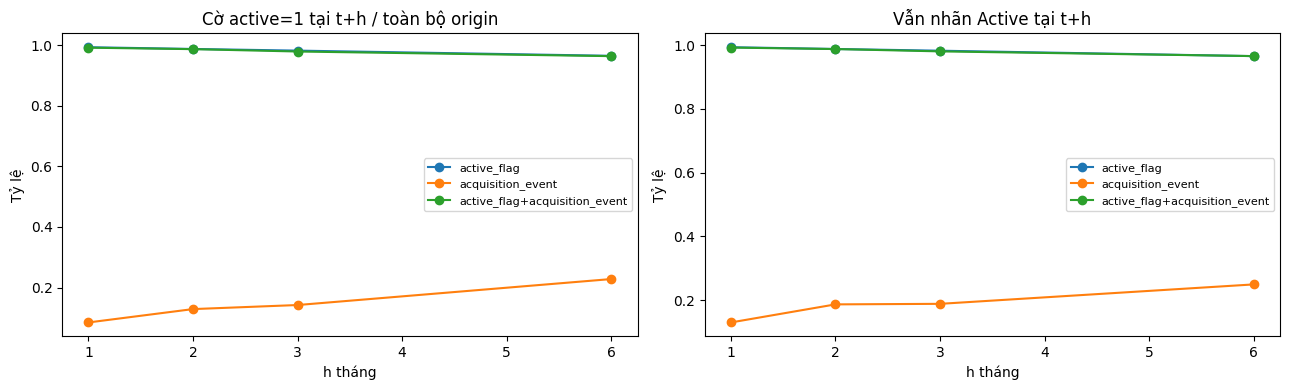

In [24]:
active_review = review_rates(review_common[review_common.source_lifecycle=='Active'],['source_reason','horizon'])
show_compact(active_review,columns=['source_reason', 'horizon', 'n_origins', 'active_flag_at_h_rate_all', 'same_lifecycle_at_h_rate', 'drop_coverage_at_h', 'drop_at_h_rate_eligible'],pct=['active_flag_at_h_rate_all', 'same_lifecycle_at_h_rate', 'drop_coverage_at_h', 'drop_at_h_rate_eligible'])
active_review.to_csv(OUTPUT_DIR/'active_reason_future_behavior.csv',index=False)
fig,axs=plt.subplots(1,2,figsize=(13,4))
for reason,g in active_review.groupby('source_reason',observed=True):
    axs[0].plot(g.horizon,g.active_flag_at_h_rate_all,marker='o',label=str(reason))
    axs[1].plot(g.horizon,g.same_lifecycle_at_h_rate,marker='o',label=str(reason))
axs[0].set(title='Cờ active=1 tại t+h / toàn bộ origin',xlabel='h tháng',ylabel='Tỷ lệ')
axs[1].set(title='Vẫn nhãn Active tại t+h',xlabel='h tháng',ylabel='Tỷ lệ')
for ax in axs: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Nhận xét — snapshot 01/2015–05/2016:**

Acquisition-only có 10.597 lượt nguồn: chỉ 8,52% có cờ active=1 và 12,98% còn nhãn Active tháng sau, so với khoảng 99% ở hai nhóm có cờ active. Có cơ sở thử tách acquisition thành cờ riêng nếu cần, nhưng v1 vẫn được giữ. Drop tháng sau 45,38% ở nhóm acquisition-only không xác nhận chính sản phẩm mới thêm đã bị bỏ.


### 10.3. Hồi phục sau active 1→0
Lấy **drop_age=0, observed, source active-drop**: một mốc khởi đầu cho mỗi đợt giảm được xác nhận và chưa được acquisition giải tỏa ngay. Đo cờ active=1 xuất hiện trong 1/2/3/6 tháng tiếp theo. Đây là mẫu có điều kiện theo rule hiện tại, không bao gồm mọi raw active-drop bị New/acquisition ưu tiên che nhãn.

Nếu hồi phục tập trung sớm, cửa sổ cảnh báo ngắn có cơ sở. Nếu nhiều đợt hồi phục sau tháng 2, cần cân nhắc giữ cảnh báo dài hơn tùy mục tiêu; không có ngưỡng tốt nhất chỉ từ một tỷ lệ. Dùng mẫu số chung giữa horizon; các đợt của cùng khách không độc lập.


,horizon,n_origins,observed_at_h_rate,active_flag_within_h_rate,active_flag_at_h_rate_all
0,1,20580,93.49%,22.00%,22.00%
1,2,20580,92.31%,30.42%,25.76%
2,3,20580,91.72%,35.95%,29.41%
3,6,20580,90.00%,44.83%,33.19%


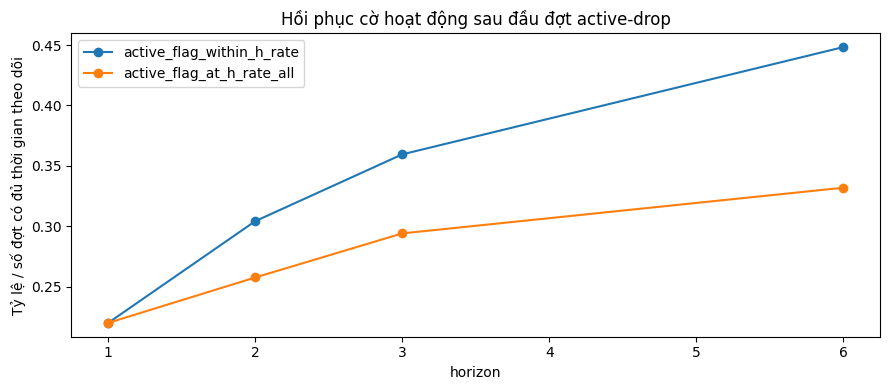

In [25]:
drop_origin = review_common[(review_common.source_reason=='recent_active_drop') & review_common.source_observed & (review_common.drop_age_at_origin==0)]
drop_review = review_rates(drop_origin,['horizon'])
show_compact(drop_review,columns=['horizon', 'n_origins', 'observed_at_h_rate', 'active_flag_within_h_rate', 'active_flag_at_h_rate_all'],pct=['observed_at_h_rate', 'active_flag_within_h_rate', 'active_flag_at_h_rate_all'])
drop_review.to_csv(OUTPUT_DIR/'active_drop_onset_recovery.csv',index=False)
if not drop_review.empty:
    drop_review.plot(x='horizon',y=['active_flag_within_h_rate','active_flag_at_h_rate_all'],marker='o',figsize=(9,4),title='Hồi phục cờ hoạt động sau đầu đợt active-drop')
    plt.ylabel('Tỷ lệ / số đợt có đủ thời gian theo dõi'); plt.tight_layout(); plt.show()


**Nhận xét — snapshot 01/2015–05/2016:**

Từ 20.580 đầu đợt active-drop, tỷ lệ đã từng hồi phục trong 1/2/3/6 tháng là 22,00% / 30,42% / 35,95% / 44,83%. Từ tháng 2 đến 3 tăng 5,53 điểm phần trăm. Có thể giữ cửa sổ 2 tháng làm baseline; chưa chứng minh 2 hay 3 tối ưu. Mẫu không gồm mọi raw active-drop bị nhãn New/acquisition ưu tiên che.


### 10.4. Vắng đến tháng thứ k: có quay lại trong h tháng tiếp không?
Mốc nguồn là các dòng **vắng thật**. Gap 1–5 giữ riêng; 6 là 6+ (nhóm cuối có thể có nhiều mốc trong cùng đợt). `observed_within_h_rate` đo đã có lại snapshot, `active_flag_within_h_rate` đo đã có snapshot kèm active=1. Các kết quả này không phụ thuộc nhãn Churned tương lai.

Đây là khả năng quay lại **có điều kiện đã vắng k tháng**, không phải xác suất trên mọi khách hay mọi đợt vắng. Chọn ngưỡng 2/3/4… cần cân bằng cảnh báo sớm và gán vắng dài hạn cho khách còn thường quay lại. Không xác nhận churn ngân hàng.


In [26]:
gap_review = review_rates(review_common[~review_common.source_observed],['gap_at_origin','horizon'])
show_compact(gap_review[gap_review.horizon==6],columns=['gap_at_origin', 'n_origins', 'observed_within_h_rate', 'active_flag_within_h_rate'],pct=['observed_within_h_rate', 'active_flag_within_h_rate'])
gap_review.to_csv(OUTPUT_DIR/'gap_length_future_return.csv',index=False)
if SHOW_DETAILS:
    fig,axs=plt.subplots(1,2,figsize=(13,4))
    for h,g in gap_review.groupby('horizon',observed=True):
        axs[0].plot(g.gap_at_origin,g.observed_within_h_rate,marker='o',label=f'h={h}')
        axs[1].plot(g.gap_at_origin,g.active_flag_within_h_rate,marker='o',label=f'h={h}')
    for ax,title in zip(axs,['Có lại snapshot trong h tháng','Có snapshot và active=1 trong h tháng']):
        ax.set(title=title,xlabel='Gap tại mốc nguồn (6 = 6+)',ylabel='Tỷ lệ'); ax.legend()
    plt.tight_layout(); plt.show()


,gap_at_origin,n_origins,observed_within_h_rate,active_flag_within_h_rate
3,1,21482,36.41%,8.54%
7,2,17162,32.33%,6.15%
11,3,13753,28.14%,5.14%
15,4,10871,21.86%,4.08%
19,5,8303,14.65%,3.46%
23,6,15218,2.79%,2.18%


**Nhận xét — snapshot 01/2015–05/2016:**

Sau khi đã vắng 3 tháng, 28,14% mốc nguồn có lại snapshot trong 6 tháng tiếp, nhưng chỉ 5,14% có snapshot kèm active=1. Gap 6+ có 2,79% quay lại; nhóm này gộp nhiều độ dài và nhiều mốc trong cùng đợt, nên chưa dùng để đổi threshold thành 6. Churned hiện tại vẫn là panel-absence proxy.


### 10.5. Lifecycle hiện tại có phân biệt hành vi tương lai?
Đo acquisition/drop **ở t+h**, với coverage và mẫu số eligible. Đây là kiểm tra độc lập hơn bảng hành vi cùng tháng vì acquisition ở t không trực tiếp định nghĩa kết quả ở t+h. Khác biệt có thể do portfolio/cohort/cờ active ban đầu; chưa chứng minh nhãn lifecycle có thông tin bổ sung so với các feature gốc.

Bảng theo tháng/cohort dùng để xem chênh lệch có lặp lại không, nhất là cohort July 2015. Nếu mục tiêu sau này là tăng chất lượng recommendation, vẫn cần so sánh model có/không lifecycle trên cùng temporal split.

Biểu đồ dùng datetime/sort tháng; không dùng same-lifecycle của New/Win-back làm thước đo retention.


In [27]:
future_review = review_rates(review_common,['source_lifecycle','horizon'])
show_compact(future_review[future_review.horizon==3],columns=['source_lifecycle', 'n_origins', 'observed_at_h_rate', 'acq_coverage_at_h', 'acq_at_h_rate_eligible', 'drop_coverage_at_h', 'drop_at_h_rate_eligible'],pct=['observed_at_h_rate', 'acq_coverage_at_h', 'acq_at_h_rate_eligible', 'drop_coverage_at_h', 'drop_at_h_rate_eligible'])
future_review.to_csv(OUTPUT_DIR/'lifecycle_future_behavior.csv',index=False)
# Horizon 3 giữ mọi tháng nguồn đủ 3 tháng, xem ổn định theo calendar.
monthly_future = review_rates(review[review.horizon==3],['origin_month','source_lifecycle','horizon'])
monthly_future.to_csv(OUTPUT_DIR/'lifecycle_future_behavior_by_month.csv',index=False)
cohort_future = review_rates(review_common[review_common.horizon==3],['cohort','is_left_censored','source_lifecycle','horizon'])
cohort_future.to_csv(OUTPUT_DIR/'lifecycle_future_behavior_by_cohort.csv',index=False)
if SHOW_DETAILS:
    fig,ax=plt.subplots(figsize=(12,5))
    for life,g in monthly_future.groupby('source_lifecycle',observed=True):
        g = g.sort_values('origin_month')
        ax.plot(pd.to_datetime(g.origin_month),g.acq_at_h_rate_eligible,marker='o',label=str(life))
    ax.set(title='Acquisition tại t+3 theo lifecycle tháng t — chỉ cặp eligible',ylabel='Tỷ lệ')
    ax.tick_params(axis='x',rotation=45); ax.legend(); plt.tight_layout(); plt.show()


,source_lifecycle,n_origins,observed_at_h_rate,acq_coverage_at_h,acq_at_h_rate_eligible,drop_coverage_at_h,drop_at_h_rate_eligible
2,Churned,48145,15.10%,12.50%,5.02%,12.50%,2.06%
6,Win-back,295,99.32%,99.32%,13.31%,99.32%,13.31%
10,New,570583,98.63%,98.56%,2.40%,98.56%,2.37%
14,At-risk,69984,55.40%,51.44%,5.31%,51.44%,4.40%
18,Active,3802002,99.80%,99.78%,6.74%,99.78%,6.99%
22,Inactive,3682444,99.44%,99.37%,0.35%,99.37%,0.46%
26,Unknown,26648,34.51%,34.44%,1.53%,8.08%,17.84%


**Nhận xét — snapshot 01/2015–05/2016:**

Ở t+3, acquisition Active 6,74% với coverage 99,78%; Inactive 0,35% với coverage 99,37%; New 2,40% với coverage 98,56%. At-risk 5,31% chỉ trên coverage 51,44%, nên không xếp hạng cả nhóm trực tiếp. Win-back chỉ 295 lượt nguồn và Unknown coverage thấp: đọc thận trọng. Khác biệt hành vi chưa chứng minh lifecycle thêm giá trị dự báo so với feature gốc.


### 10.6. Ghi quyết định sau EDA
| Vấn đề | Bằng chứng cần đọc | Quyết định có thể thử |
|---|---|---|
| Active do acquisition | Active reason + cờ active tương lai + coverage | Giữ rule hoặc dùng acquisition làm cờ riêng |
| At-risk do active giảm | Hồi phục từ drop-age=0 qua cùng origin | So sánh cửa sổ 1/2/3 tháng |
| Churned proxy | Quay lại sau gap k theo cùng horizon | So sánh ngưỡng vắng 2/3/4 tháng |
| Giá trị segmentation | Acquisition/drop tương lai qua tháng/cohort | Giữ lifecycle làm ngữ cảnh hoặc thêm feature giải thích |

Không chọn threshold chỉ để nhiều trạng thái hơn hoặc tỷ lệ hồi phục nhỏ hơn. Chọn theo ứng dụng và kiểm tra trên giai đoạn khác. Các bảng toàn kỳ là exploratory; nếu dùng chúng để quyết định rule, giai đoạn đã xem không còn là holdout hoàn toàn chưa đụng tới.


In [28]:
assert not review.empty
assert (review.observed_within_h <= review.n_origins).all()
assert (review.active_flag_within_h <= review.observed_within_h).all()
assert (review.acq_at_h <= review.acq_eligible_at_h).all()
assert (review.drop_at_h <= review.drop_eligible_at_h).all()
assert (review.active_flag_at_h <= review.active_known_at_h).all()
assert all((pd.Period(m,freq='M')+int(h))<=pd.Period(END_MONTH,freq='M') for m,h in review[['origin_month','horizon']].drop_duplicates().itertuples(index=False,name=None))
print('EDA bổ sung hoàn tất. Rule vẫn:',cfg.rule_version,'— thresholds:',cfg.new_months,cfg.missing_for_churn,cfg.active_drop_window)


EDA bổ sung hoàn tất. Rule vẫn: lifecycle-v1 — thresholds: 2 3 2


**Nhận xét — snapshot 01/2015–05/2016:**

Các kiểm tra mẫu số/endpoint/follow-up đều đạt. Chưa chạy model, chưa so sánh v1/v2 và chưa thay ngưỡng; EDA đủ để hiểu và dùng v1 làm ngữ cảnh, không bắt buộc phải sửa rule.
